# 00 First look

Profile of the 11 raw tables before any cleaning. Same checks on every table:
shape and `head()`, `describe()`, `value_counts()`, histograms of the numeric columns.
Each station ends with the issues found; the full list drives the cleaning rules in
`src/ssc_coh/clean.py`. Raw files are not modified.

Tables are opened in the order a patient moves through the clinic:

1. registration desk (`demographics`)
2. rheumatologist (`ssc_subtype`)
3. nurse (`vitals`)
4. clinical laboratory (`lab_report`) and immunology laboratory (`antibodies`)
5. skin score (`mrss`)
6. lung function (`pft`)
7. pharmacy (`medications`)
8. bronchoscopy (`bal`)
9. RNA-seq libraries (`libraries`)
10. skin biopsy (`skin_biopsies`)

In [1]:
# Imports, project configuration, display settings, the three helpers used at every station, and the 11 raw tables
import sys

sys.path.insert(0, "../src")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

from ssc_coh.config import CONTROL_PREFIX, DATE_COLS, ID_COLS, MEDICATION_ALIASES, RAW_DIR, REFERENCE_DATE, TABLES

pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 30)
pd.set_option("display.max_colwidth", 120)

GREY, RED, BLUE, ORANGE = "#9AA3AD", "#E0483B", "#2E6FE0", "#E88712"
RED_FILL = "background-color: #F8D7D3; font-weight: bold"
GREEN_FILL = {"background-color": "#DDF0E8"}


def checks_table(pairs):
    """Turn a list of (check, result) pairs into a two-column table, one row per check."""
    return pd.DataFrame(pairs, columns=["check", "result"])


def ids_not_registered(table, id_column):
    """Ids in this table that are not in demographics."""
    # reads registered_ids, the notebook-level set built at station 1 below; every call
    # to this function sits at a later station, so the set is always defined by then
    return sorted(set(table[id_column]) - registered_ids)


def parse_date_column(table, column):
    """Parse one date column. Returns the parsed dates and how many non-empty values did not parse."""
    parsed = pd.to_datetime(table[column], errors="coerce")
    n_unparseable = int((table[column].notna() & parsed.isna()).sum())
    return parsed, n_unparseable


def red_if_nonzero(value):
    """Cell style for the highlighted crosstabs: red where the count is not zero."""
    return RED_FILL if value else ""


# the TABLES whitelist in config.py, not everything in the directory, so a stray file cannot enter the audit
raw_tables = {table_name: pd.read_csv(RAW_DIR / f"{table_name}.csv", low_memory=False) for table_name in TABLES}
pd.DataFrame({"rows": {name: len(table) for name, table in raw_tables.items()},
              "columns": {name: table.shape[1] for name, table in raw_tables.items()},
              "patient id column (ID_COLS)": ID_COLS,
              "first columns": {name: ", ".join(table.columns[:4]) for name, table in raw_tables.items()}})

,rows,columns,patient id column (ID_COLS),first columns
antibodies,3511,4,case_number,"case_number, dts, test, value"
bal,1170,7,reg_id,"bal_id, reg_id, procedure_date, procedure_site"
demographics,1500,12,case number,"study, case number, first name, last name"
lab_report,30941,4,reg_id,"reg_id, order_date, component_name, value"
libraries,918,24,reg_id,"reg_id, cell_viability, processing_date, comment"
medications,3273,4,reg_id,"reg_id, date, medication, dose"
mrss,3113,4,reg_id,"reg_id, date, ENTRY_USER_NAME, mrss_score"
pft,5069,5,case_number,"case_number, PFT_dts, DESCRIPTION, NAME"
skin_biopsies,215,8,case_number,"case_number, biopsy_date, ENTRY_USER_NAME, biopsy_site"
ssc_subtype,1500,7,study_code,"study_code, ssc_subtype, other_dx, raynaud_date"


Patient id column has four names across tables: `case number` (with a space),
`case_number`, `reg_id`, `study_code`; `ID_COLS` in `config.py` records which table uses which. Cleaning normalizes them to one name.

## Station 1: demographics (registration desk; one row per patient)

In [2]:
# Open demographics and build the registered-id set that every later station checks against
demographics = raw_tables["demographics"]
registered_ids = set(demographics["case number"])
display(checks_table([("one row per patient", demographics["case number"].is_unique),
                      ("rows", len(demographics))]))
demographics.head()

,check,result
0,one row per patient,True
1,rows,1500


,study,case number,first name,last name,birth date,ethnicity,gender,races,diagnosis,state,height,weight
0,SSC-REG,subject_7250,Danielle,Taylor,1951-07-24,Not Hispanic or Latino,Female,White,SSc,CA,62.7,173.5
1,SSC-REG,subject_4646,Minji,Kato,1957-12-01,Not Hispanic or Latino,Female,Asian,SSc,IL,67.1,129.9
2,SSC-REG,subject_7910,Kimberly,Morris,1972-10-12,Not Hispanic or Latino,Female,Black or African American,SSc,MI,67.9,141.6
3,SSC-REG,subject_7832,Isabella,Clark,1963-10-18,Not Hispanic or Latino,Female,White,SSc,IL,62.9,181.0
4,SSC-REG,subject_3962,Brenda,Morris,1988-09-03,Not Hispanic or Latino,Female,White,SSc,CA,65.4,167.6


In [3]:
# Numeric summary of the two measurement columns
demographics.describe()

,height,weight
count,1500.000000,1500.000000
mean,82.401800,163.724133
std,38.349639,33.570595
min,54.700000,22.500000
25%,62.900000,140.100000
50%,65.500000,161.950000
75%,69.525000,187.400000
max,194.700000,274.000000


In [4]:
# Value counts of the categorical columns, with the share of rows, and the state column on its own
demographics_categorical_counts = pd.concat({column: demographics[column].value_counts(dropna=False)
                                             for column in ["study", "diagnosis", "gender", "ethnicity", "races"]})
demographics_categorical_counts = demographics_categorical_counts.rename("rows").rename_axis(["column", "value"]).to_frame()
demographics_categorical_counts["share_pct"] = (demographics_categorical_counts["rows"] / len(demographics) * 100).round(1)
display(demographics_categorical_counts)
display(checks_table([("distinct states", demographics["state"].nunique())]))
demographics["state"].value_counts().head(5).rename("rows").to_frame()

rows  share_pct
column    value                                     
study     SSC-REG                    1500      100.0
diagnosis SSc                        1500      100.0
gender    Female                     1237       82.5
          Male                        263       17.5
ethnicity Not Hispanic or Latino     1342       89.5
          Hispanic or Latino          158       10.5
races     White                       858       57.2
          Black or African American   331       22.1
          Asian                       163       10.9
          Other                       148        9.9

,check,result
0,distinct states,8


,rows
state,
CA,664
NY,129
OH,126
IN,123
TX,121


- `study` and `diagnosis` are constant, so they carry no information.
- `gender` is 82% female, which matches SSc epidemiology (about 4 to 5 women per man) and is therefore expected.
- `height` runs 54.7 to 194.7 and `weight` goes down to 22.5, out of range for any single unit; see the histograms.

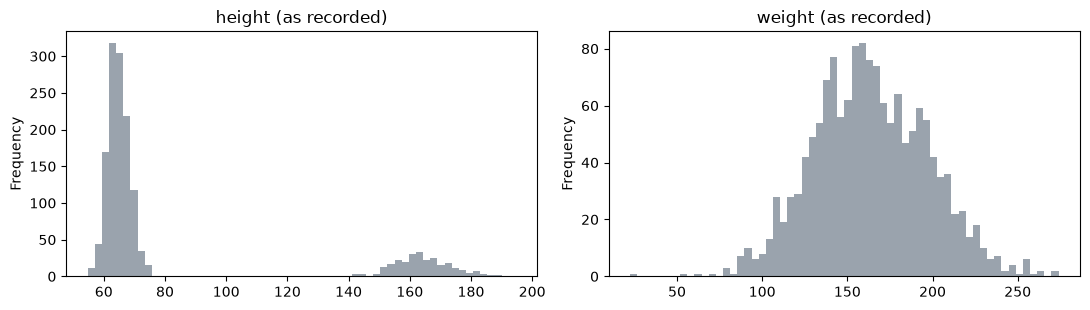

In [5]:
# Histograms of height and weight as recorded
fig, axes = plt.subplots(1, 2, figsize=(11, 3.2))
demographics["height"].plot.hist(bins=60, ax=axes[0], title="height (as recorded)", color=GREY)
demographics["weight"].plot.hist(bins=60, ax=axes[1], title="weight (as recorded)", color=GREY)
plt.tight_layout()

In [6]:
# Split the height column at 100, and look at the lightest registrations
height_is_cm = demographics["height"] >= 100
display(checks_table([("height below 100 (inches)", int((~height_is_cm).sum())),
                      ("height 100 or more (cm)", int(height_is_cm.sum()))]))
demographics.nsmallest(8, "weight")[["case number", "height", "weight"]]

,check,result
0,height below 100 (inches),1235
1,height 100 or more (cm),265


,case number,height,weight
540,subject_8545,63.9,22.5
1310,subject_2170,60.9,54.7
254,subject_5342,62.2,64.0
834,subject_7662,161.0,69.9
599,subject_6519,64.7,77.7
699,subject_7235,66.6,78.1
136,subject_5413,63.7,80.1
485,subject_5392,64.6,84.3


- Height has two clusters, 55 to 78 and 140 to 195: inches and cm mixed in one column. A threshold of 100 separates them (1,235 / 265).
- Weight: 5 rows at 54.7 to 78.1 read as kg; `subject_8545` = 22.5 at 63.9 in is impossible in any unit, so it becomes missing.
- The histogram cannot show whether the 265 cm-height rows also carry kg weights; the BMI check below settles it.

In [7]:
# Height in cm and BMI under both readings of the weight column, as columns on demographics; then the by-patient index used at station 3
height_cm = demographics["height"].where(height_is_cm, demographics["height"] * 2.54)    # heights below 100 are inches, converted to cm
height_m2 = (height_cm / 100) ** 2
demographics = demographics.assign(height_cm=height_cm,
                                   bmi_if_lb=(demographics["weight"] / 2.20462) / height_m2,
                                   bmi_if_kg=demographics["weight"] / height_m2)
demographics_by_patient = demographics.set_index("case number")
weight_below_80 = demographics["weight"] < 80
display(checks_table([
    ("BMI median if weight is lb, cm-height rows", round(demographics.loc[height_is_cm, "bmi_if_lb"].median(), 1)),
    ("BMI median if weight is lb, inch-height rows", round(demographics.loc[~height_is_cm, "bmi_if_lb"].median(), 1)),
    ("BMI median if weight is kg, cm-height rows", round(demographics.loc[height_is_cm, "bmi_if_kg"].median(), 1)),
]))
demographics.loc[weight_below_80, ["case number", "height", "weight", "bmi_if_lb", "bmi_if_kg"]].round(1).sort_values("weight")

,check,result
0,"BMI median if weight is lb, cm-height rows",27.4
1,"BMI median if weight is lb, inch-height rows",27.0
2,"BMI median if weight is kg, cm-height rows",60.3


,case number,height,weight,bmi_if_lb,bmi_if_kg
540,subject_8545,63.9,22.5,3.9,8.5
1310,subject_2170,60.9,54.7,10.4,22.9
254,subject_5342,62.2,64.0,11.6,25.6
834,subject_7662,161.0,69.9,12.2,27.0
599,subject_6519,64.7,77.7,13.1,28.8
699,subject_7235,66.6,78.1,12.4,27.3


- For the 265 cm-height rows the BMI median is 27.4 with weight read as lb (the inch-height rows give 27.0) and 60 with weight read as kg, so their weights are lb. Height unit and weight unit are independent.
- Of the 6 rows under 80, reading the weight as lb gives BMI 3.9 to 13.1 (not survivable); reading it as kg gives 22.9 to 28.8 for five of them, so those five are kg. `subject_8545` fails both readings.
- Per-row confirmation against the BMI recorded by nurses in vitals: station 3.

In [8]:
# Duplicate ids, and people registered twice under different ids (same name and birth date)
duplicate_registrations = demographics[demographics.duplicated(subset=["first name", "last name", "birth date"], keep=False)]
display(checks_table([("duplicate ids", int(demographics["case number"].duplicated().sum())),
                      ("rows sharing name and birth date under different ids", len(duplicate_registrations))]))
duplicate_registrations.sort_values(["last name", "first name"])[["case number", "first name", "last name", "birth date", "height", "weight", "state"]]

,check,result
0,duplicate ids,0
1,rows sharing name and birth date under different ids,4


,case number,first name,last name,birth date,height,weight,state
328,subject_8994,Abigail,Bailey,1973-05-04,61.5,133.8,CA
1143,subject_5465,Abigail,Bailey,1973-05-04,61.5,133.8,CA
35,subject_7539,Alexis,Pierce,1971-10-28,63.4,159.5,IN
311,subject_3700,Alexis,Pierce,1971-10-28,63.4,159.5,CA


- No duplicate ids.
- Two pairs share name, birth date, height and weight under different ids: duplicate registrations (one pair registered in IN and CA). The canonical id will be the one with more longitudinal rows, decided once the long tables are loaded.

In [9]:
# Birth dates, and the age they imply at the reference date
birth_date, n_unparseable_birth_dates = parse_date_column(demographics, "birth date")
age_years = (pd.Timestamp(REFERENCE_DATE) - birth_date).dt.days / 365.25
checks_table([("unparseable birth dates", n_unparseable_birth_dates),
              ("age range (years)", f"{age_years.min():.0f} to {age_years.max():.0f}")])

,check,result
0,unparseable birth dates,0
1,age range (years),36 to 82


### Issue list after station 1

| # | table | what | why it matters | action |
|---|---|---|---|---|
| 1 | demographics | height in two units (inches / cm, split at 100) | every BMI, every plot on height is wrong until fixed | convert to one unit |
| 2 | demographics | a few weights look like kg among lb (rows < 80) | same as issue 1 | convert to lb; the exact list comes at station 3 |
| 3 | demographics | one weight (22.5) impossible in any unit | cannot be fixed | missing + logged |
| 4 | demographics | two duplicate registrations (same name + DOB, different ids) | one person counted twice; longitudinal records split | one canonical id per person, chosen after the long tables are loaded |
| 5 | all tables | patient id under four column names, one with a space | joins fail until the names agree | rename to one id column |

## Station 2: ssc_subtype (rheumatologist; one row per patient with subtype, comorbidities and milestone dates)

In [10]:
# Open ssc_subtype and build the subtype lookup that every later station reuses
ssc_subtype = raw_tables["ssc_subtype"]
subtype_by_patient = ssc_subtype.set_index("study_code")["ssc_subtype"]
display(checks_table([("rows", len(ssc_subtype)),
                      ("one row per patient", ssc_subtype["study_code"].is_unique),
                      ("same ids as demographics", set(ssc_subtype["study_code"]) == registered_ids)]))
ssc_subtype.head()

,check,result
0,rows,1500
1,one row per patient,True
2,same ids as demographics,True


,study_code,ssc_subtype,other_dx,raynaud_date,nonraynaud_date,nonraynaud_sx,diagnosis_date
0,subject_7250,lcSSc,NaN,2015-10-10,2018-01-29,arthralgia,2020-12-18
1,subject_4646,dcSSc,NaN,2012-10-11,2016-04-10,puffy hands,2018-09-24
2,subject_7910,dcSSc,ILD; GERD,2012-08-19,2012-08-17,GERD,2014-12-30
3,subject_7832,lcSSc,NaN,2010-08-03,2017-07-02,dyspnea,2019-02-26
4,subject_3962,dcSSc,ILD; GERD,2012-04-12,2016-09-30,GERD,2020-08-23


In [11]:
# Subtype, first non-Raynaud symptom, and the free-text comorbidity column; the ILD lookup is built from other_dx here
ild_by_patient = ssc_subtype.set_index("study_code")["other_dx"].fillna("").str.contains("ILD")
display(ssc_subtype["ssc_subtype"].value_counts(dropna=False).rename("rows").to_frame())
display(ssc_subtype["nonraynaud_sx"].value_counts(dropna=False).rename("rows").to_frame())
display(checks_table([("other_dx missing", f"{ssc_subtype['other_dx'].isna().mean():.0%}"),
                      ("patients with ILD in other_dx", int(ild_by_patient.sum()))]))
ssc_subtype["other_dx"].value_counts().head(6).rename("rows").to_frame()

,rows
ssc_subtype,
lcSSc,900
dcSSc,600


,rows
nonraynaud_sx,
dyspnea,317
arthralgia,315
puffy hands,296
GERD,289
digital ulcers,283


,check,result
0,other_dx missing,37%
1,patients with ILD in other_dx,635


,rows
other_dx,
ILD,434
GERD,230
ILD; GERD,164
PAH,56
ILD; PAH,25
GERD; PAH,24


- Ids match demographics exactly (the same 1,500 people).
- `ssc_subtype` is 900 limited / 600 diffuse, the main grouping variable of the whole dataset; both values are spelled one way.
- `nonraynaud_sx` is a fixed set of symptom labels with no spelling variants.
- `other_dx` is free text with semicolons (`ILD; GERD`) and 37% missing. A missing value means the comorbidity was not recorded; it does not mean there is none. It needs parsing into per-condition flags (ILD, GERD, PAH). The `ild_by_patient` lookup built above reads a missing value as no ILD, which is the caveat to keep in mind where it is used at stations 6 to 8.

In [12]:
# Parse the three milestone dates in place, check their order, and build the diagnosis-date lookup used at stations 7 to 10
raynaud_date, n_unparseable_raynaud = parse_date_column(ssc_subtype, "raynaud_date")
nonraynaud_date, n_unparseable_nonraynaud = parse_date_column(ssc_subtype, "nonraynaud_date")
diagnosis_date, n_unparseable_diagnosis = parse_date_column(ssc_subtype, "diagnosis_date")
ssc_subtype = ssc_subtype.assign(raynaud_date=raynaud_date, nonraynaud_date=nonraynaud_date, diagnosis_date=diagnosis_date)
diagnosis_date_by_patient = ssc_subtype.set_index("study_code")["diagnosis_date"]
raynaud_after_nonraynaud = ssc_subtype["raynaud_date"] > ssc_subtype["nonraynaud_date"]
share_raynaud_after = raynaud_after_nonraynaud.mean()
onset_gap_years = (ssc_subtype["nonraynaud_date"] - ssc_subtype["raynaud_date"]).dt.days / 365.25
checks_table([
    ("unparseable raynaud_date / nonraynaud_date / diagnosis_date", f"{n_unparseable_raynaud} / {n_unparseable_nonraynaud} / {n_unparseable_diagnosis}"),
    ("missing raynaud_date / nonraynaud_date / diagnosis_date", f"{ssc_subtype['raynaud_date'].isna().sum()} / {ssc_subtype['nonraynaud_date'].isna().sum()} / {ssc_subtype['diagnosis_date'].isna().sum()}"),
    ("raynaud_date range", f"{ssc_subtype['raynaud_date'].min().date()} to {ssc_subtype['raynaud_date'].max().date()}"),
    ("nonraynaud_date range", f"{ssc_subtype['nonraynaud_date'].min().date()} to {ssc_subtype['nonraynaud_date'].max().date()}"),
    ("diagnosis_date range", f"{ssc_subtype['diagnosis_date'].min().date()} to {ssc_subtype['diagnosis_date'].max().date()}"),
    ("Raynaud date after non-Raynaud date", int(raynaud_after_nonraynaud.sum())),
    ("share of patients", f"{share_raynaud_after:.1%}"),
    ("diagnosis before non-Raynaud date", int((ssc_subtype["diagnosis_date"] < ssc_subtype["nonraynaud_date"]).sum())),
    ("diagnosis before Raynaud date", int((ssc_subtype["diagnosis_date"] < ssc_subtype["raynaud_date"]).sum())),
])

,check,result
0,unparseable raynaud_date / nonraynaud_date / diagnosis_date,0 / 0 / 0
1,missing raynaud_date / nonraynaud_date / diagnosis_date,0 / 0 / 0
2,raynaud_date range,2006-12-23 to 2020-10-30
3,nonraynaud_date range,2011-01-06 to 2021-05-02
4,diagnosis_date range,2014-07-22 to 2022-01-03
5,Raynaud date after non-Raynaud date,308
6,share of patients,20.5%
7,diagnosis before non-Raynaud date,51
8,diagnosis before Raynaud date,0


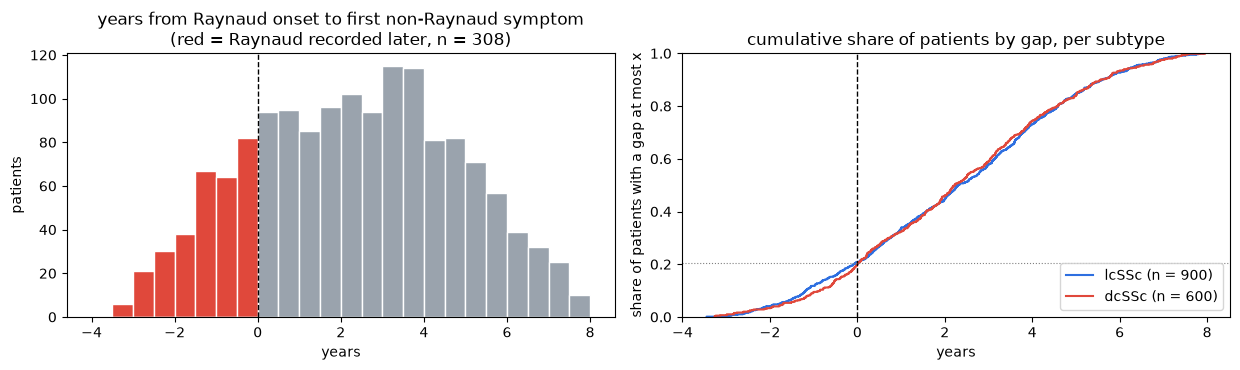

In [13]:
# Histogram of the gap in half-year bins with the negatives in red, and the cumulative share of patients by gap for each subtype
fig, (ax_hist, ax_ecdf) = plt.subplots(1, 2, figsize=(12.5, 3.8))
bin_edges = np.arange(-4, 8.5, 0.5)
onset_gap_years[onset_gap_years < 0].plot.hist(bins=bin_edges, ax=ax_hist, color=RED, edgecolor="white")
onset_gap_years[onset_gap_years >= 0].plot.hist(bins=bin_edges, ax=ax_hist, color=GREY, edgecolor="white")
ax_hist.axvline(0, color="black", lw=1, ls="--")
ax_hist.set_title(f"years from Raynaud onset to first non-Raynaud symptom\n(red = Raynaud recorded later, n = {int(raynaud_after_nonraynaud.sum())})")
ax_hist.set_xlabel("years")
ax_hist.set_ylabel("patients")
for subtype, line_color in [("lcSSc", BLUE), ("dcSSc", RED)]:
    subtype_gaps = onset_gap_years[ssc_subtype["ssc_subtype"] == subtype]
    ax_ecdf.ecdf(subtype_gaps, color=line_color, label=f"{subtype} (n = {len(subtype_gaps)})")
ax_ecdf.axvline(0, color="black", lw=1, ls="--")
ax_ecdf.axhline(share_raynaud_after, color="grey", lw=0.8, ls=":")     # the overall share with a negative gap
ax_ecdf.set_title("cumulative share of patients by gap, per subtype")
ax_ecdf.set_xlabel("years")
ax_ecdf.set_ylabel("share of patients with a gap at most x")
ax_ecdf.legend(loc="lower right")
plt.tight_layout()

In [14]:
# The negative gaps in numbers: how many, how large, and the rate in each subtype
negative_gaps = onset_gap_years[raynaud_after_nonraynaud]
display(checks_table([
    ("patients with Raynaud recorded later", f"{len(negative_gaps)} ({share_raynaud_after:.1%})"),
    ("negative gap median (years)", round(negative_gaps.median(), 1)),
    ("negative gap range (years)", f"{negative_gaps.min():.2f} to {negative_gaps.max():.2f}"),
    ("patients within 30 days of zero (near-simultaneous onset)", int((onset_gap_years.abs() < 30 / 365.25).sum())),
]))
(raynaud_after_nonraynaud.groupby(ssc_subtype["ssc_subtype"]).mean() * 100).round(1).rename("Raynaud recorded later, % of patients").to_frame()

,check,result
0,patients with Raynaud recorded later,308 (20.5%)
1,negative gap median (years),-1.1
2,negative gap range (years),-3.45 to -0.00
3,patients within 30 days of zero (near-simultaneous onset),32


,"Raynaud recorded later, % of patients"
ssc_subtype,
dcSSc,20.2
lcSSc,20.8


- All three dates parse; ranges are plausible.
- Onset order: 308 patients (20.5%) have Raynaud's recorded *after* the first non-Raynaud symptom. Non-Raynaud-first onset is clinically real but is a feature of diffuse disease; here the rate is identical in both subtypes (20.8% vs 20.2%). The histogram shows the negatives as the left tail of one smooth bell (median −1.1 years, only 32 patients within 30 days of zero), with no cluster at zero and no mirror image of the positives. The order was never enforced when the data was generated; this is not biology. The cumulative curves of the two subtypes lie on top of each other along the whole range. Flag it; do not "fix" it.
- 51 patients were diagnosed before their first non-Raynaud symptom. That is possible (Raynaud's plus antibodies can be enough), so flag only.

### Issue list after station 2

| # | table | what | why it matters | action |
|---|---|---|---|---|
| 6 | ssc_subtype | `other_dx` free text, 37% missing | comorbidity flags must treat a missing value as unknown | parse into per-condition flags; missing stays unknown |
| 7 | ssc_subtype | Raynaud date after non-Raynaud date, 308 patients, same rate in both subtypes | any "time from onset" variable is unreliable for 20% of patients | flag only; never swap the dates |
| 8 | ssc_subtype | diagnosis before first non-Raynaud symptom, 51 patients | clinically possible (Raynaud's plus antibodies can be enough) | flag only |

## Station 3: vitals (nurse; one row per measurement, long format)

In [15]:
# Open vitals; the ids that are not registered are the controls, kept as control_ids for the later stations
vitals = raw_tables["vitals"]
control_ids = set(ids_not_registered(vitals, "reg_id"))
display(checks_table([("rows", len(vitals)), ("patients", vitals["reg_id"].nunique()),
                      ("of them registered in demographics", int(vitals["reg_id"].drop_duplicates().isin(registered_ids).sum())),
                      ("registered patients in demographics", len(registered_ids)),
                      ("ids not registered in demographics", ids_not_registered(vitals, "reg_id"))]))
display(vitals["vital_type_name_category"].value_counts(dropna=False).rename("rows").to_frame())
vitals.head()

,check,result
0,rows,40250
1,patients,1503
2,of them registered in demographics,1500
3,registered patients in demographics,1500
4,ids not registered in demographics,"[SSC_NORM_0101, SSC_NORM_0102, SSC_NORM_0110]"


,rows
vital_type_name_category,
WEIGHT IN POUND,8396
PULSE,8381
BP SYSTOLIC,7848
BP DIASTOLIC,7848
BMI,7777


,reg_id,date,vital_type_name_category,vital_value
0,subject_2005,2021-04-20,BMI,33.0
1,subject_2005,2021-04-20,BP SYSTOLIC,145.0
2,subject_2005,2021-04-20,PULSE,72.0
3,subject_2005,2021-04-20,WEIGHT IN POUND,218.8
4,subject_2005,2021-04-20,BP DIASTOLIC,78.0


In [16]:
# Numeric values and parsed dates (the unparseable count is taken before the raw column is replaced); then one row per visit with one column per measure
vital_value_numeric = pd.to_numeric(vitals["vital_value"], errors="coerce")
vitals_date, n_unparseable_dates = parse_date_column(vitals, "date")
vitals = vitals.assign(value=vital_value_numeric, date=vitals_date)
vitals_by_visit = vitals.pivot_table(index=["reg_id", "date"], columns="vital_type_name_category", values="value", aggfunc="first")
display(checks_table([("non-numeric values", int((vitals["vital_value"].notna() & vitals["value"].isna()).sum())),
                      ("unparseable dates", n_unparseable_dates),
                      ("date range", f"{vitals['date'].min().date()} to {vitals['date'].max().date()}"),
                      ("visits (patient and date pairs)", len(vitals_by_visit))]))
vitals.groupby("vital_type_name_category")["value"].describe().round(1)

,check,result
0,non-numeric values,0
1,unparseable dates,0
2,date range,2014-10-27 to 2026-07-12
3,visits (patient and date pairs),9131


,count,mean,std,min,25%,50%,75%,max
vital_type_name_category,,,,,,,,
BMI,7777.0,27.6,5.8,10.3,23.7,27.1,30.8,56.7
BP DIASTOLIC,7848.0,77.3,6.5,55.0,74.0,77.0,80.0,102.0
BP SYSTOLIC,7848.0,124.6,10.2,95.0,120.0,124.0,130.0,165.0
PULSE,8381.0,75.7,8.6,50.0,70.0,76.0,81.0,110.0
WEIGHT IN POUND,8396.0,163.4,31.6,54.2,142.8,160.6,184.5,278.9


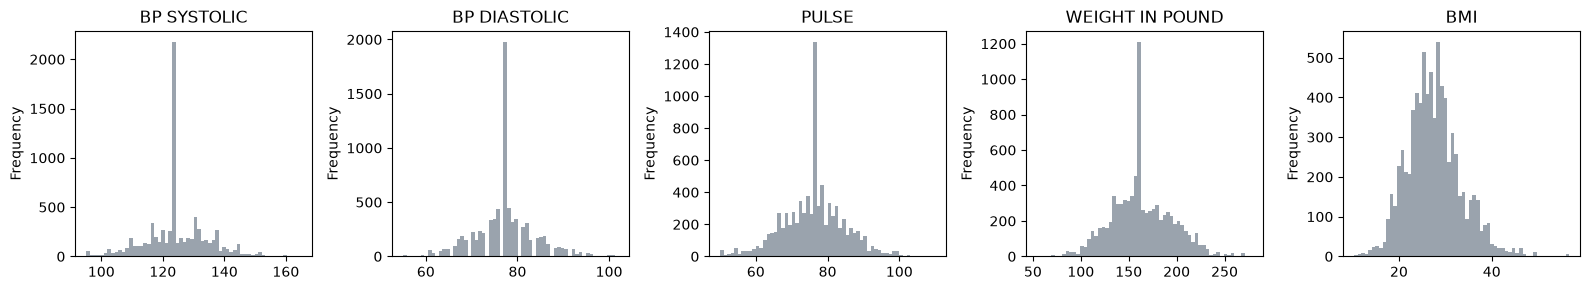

In [17]:
# Histogram of each measure
vital_measures = ["BP SYSTOLIC", "BP DIASTOLIC", "PULSE", "WEIGHT IN POUND", "BMI"]
fig, axes = plt.subplots(1, 5, figsize=(16, 3))
for ax, measure in zip(axes, vital_measures):
    vitals.loc[vitals["vital_type_name_category"] == measure, "value"].plot.hist(bins=60, ax=ax, title=measure, color=GREY)
plt.tight_layout()

In [18]:
# How many distinct values each measure takes, and its three most frequent values with their share of the rows
def top_over_second(rows):
    """How many times the most frequent value outnumbers the second most frequent one."""
    return round(rows.iloc[0] / rows.iloc[1], 1)


rows_and_distinct_by_measure = vitals.groupby("vital_type_name_category")["value"].agg(rows="size", distinct_values="nunique")
top_values_by_measure = (vitals.groupby("vital_type_name_category")["value"].value_counts()
                               .groupby(level=0).head(3).rename("rows").reset_index())
top_values_by_measure["share_pct"] = (top_values_by_measure["rows"]
                                      / top_values_by_measure["vital_type_name_category"].map(rows_and_distinct_by_measure["rows"]) * 100).round(1)
rows_and_distinct_by_measure["top_over_second"] = top_values_by_measure.groupby("vital_type_name_category")["rows"].agg(top_over_second)
display(rows_and_distinct_by_measure.loc[vital_measures])
top_values_by_measure

,rows,distinct_values,top_over_second
vital_type_name_category,,,
BP SYSTOLIC,7848,65,7.2
BP DIASTOLIC,7848,45,4.4
PULSE,8381,59,3.0
WEIGHT IN POUND,8396,1130,22.3
BMI,7777,297,1.0


,vital_type_name_category,value,rows,share_pct
0,BMI,25.1,101,1.3
1,BMI,25.2,98,1.3
2,BMI,23.4,96,1.2
3,BP DIASTOLIC,77.0,1979,25.2
4,BP DIASTOLIC,78.0,449,5.7
5,BP DIASTOLIC,76.0,439,5.6
6,BP SYSTOLIC,124.0,1988,25.3
7,BP SYSTOLIC,132.0,277,3.5
8,BP SYSTOLIC,130.0,272,3.5
9,PULSE,76.0,1339,16.0


- 1,503 ids for 1,500 registered patients: three `SSC_NORM_*` ids have vitals but no registration. By the prefix they are healthy controls from a companion study rather than this cohort, so they go to quarantine; expect them in other tables too.
- All values are numeric and all dates parse (2014 to 2026); nothing to fix at the parsing level.
- In `describe()`, BP and pulse ranges are plausible (SBP 95 to 165, DBP 55 to 102, pulse 50 to 110). BMI min 10.3 and weight min 54.2 are not: the station-1 unit problem again, now at visit level.
- Every histogram except BMI has one spike: SBP 124 (1,988 rows = 25%), DBP 77 (25%), pulse 76 (16%), weight 160.6 (870 rows = 10%). Weight has 1,130 distinct values, so one value at 22× the runner-up (39) is a filled-in default, not a measurement. BP and pulse sit on a coarse grid (65 / 45 / 59 distinct values) with the default on top.

In [19]:
# The 160.6 weight: how often it appears, on how many patients, whether it fills whole histories, and how it compares with the registration weight
DEFAULT_WEIGHT = 160.6

# 1. weight rows only, in date order, with a flag for the suspect value
vitals_weight = vitals[vitals["vital_type_name_category"] == "WEIGHT IN POUND"].sort_values("date")
vitals_weight = vitals_weight.assign(is_default_weight=vitals_weight["value"] == DEFAULT_WEIGHT)

# 2. per patient: how many weights in total, and how many of them are the default
weights_by_patient = vitals_weight.groupby("reg_id")["is_default_weight"].agg(n_weights="size", n_default="sum")
patients_with_default_weight = weights_by_patient[weights_by_patient["n_default"] > 0]
every_weight_is_default = patients_with_default_weight["n_default"] == patients_with_default_weight["n_weights"]

# 3. cross-check against an independent source: the weight recorded at registration (reindex looks up by id, order-independent)
registration_gap_lb = (demographics_by_patient["weight"].reindex(patients_with_default_weight.index) - DEFAULT_WEIGHT).abs()

checks_table([
    (f"rows at {DEFAULT_WEIGHT}", int(vitals_weight["is_default_weight"].sum())),
    (f"share of weight rows at {DEFAULT_WEIGHT}", f"{vitals_weight['is_default_weight'].mean():.1%}"),
    (f"patients with any weight at {DEFAULT_WEIGHT}", len(patients_with_default_weight)),
    ("of them, every weight is the default", int(every_weight_is_default.sum())),
    ("of them, matched to a registration record", int(registration_gap_lb.notna().sum())),
    ("of them, unmatched (the controls)", int(registration_gap_lb.isna().sum())),
    (f"registration weight more than 50 lb away from {DEFAULT_WEIGHT}", int((registration_gap_lb > 50).sum())),
    ("subject_8545 weights in vitals (registration weight 22.5)", vitals_weight.loc[vitals_weight["reg_id"] == "subject_8545", "value"].tolist()),
])

,check,result
0,rows at 160.6,870
1,share of weight rows at 160.6,10.4%
2,patients with any weight at 160.6,195
3,"of them, every weight is the default",194
4,"of them, matched to a registration record",192
5,"of them, unmatched (the controls)",3
6,registration weight more than 50 lb away from 160.6,27
7,subject_8545 weights in vitals (registration weight 22.5),"[160.6, 160.6, 160.6, 160.6, 160.6]"


In [20]:
# Patients with a recorded BMI below 15 (not survivable for long), next to their registration numbers under both readings of the weight
vitals_bmi = vitals[vitals["vital_type_name_category"] == "BMI"]
is_low_bmi = vitals_bmi["value"] < 15
low_bmi_patients = sorted(vitals_bmi.loc[is_low_bmi, "reg_id"].unique())
low_bmi_registration = demographics_by_patient.loc[low_bmi_patients, ["height", "weight", "height_cm", "bmi_if_lb", "bmi_if_kg"]].copy()
low_bmi_registration["vitals_bmi_median"] = vitals_bmi[vitals_bmi["reg_id"].isin(low_bmi_patients)].groupby("reg_id")["value"].median()
display(checks_table([("patients with any recorded BMI below 15", len(low_bmi_patients)),
                      ("rows with BMI below 15", int(is_low_bmi.sum()))]))
low_bmi_registration.sort_values("weight").round(1)

,check,result
0,patients with any recorded BMI below 15,14
1,rows with BMI below 15,60


,height,weight,height_cm,bmi_if_lb,bmi_if_kg,vitals_bmi_median
case number,,,,,,
subject_2170,60.9,54.7,154.7,10.4,22.9,11.0
subject_5342,62.2,64.0,158.0,11.6,25.6,11.8
subject_7662,161.0,69.9,161.0,12.2,27.0,12.4
subject_6519,64.7,77.7,164.3,13.1,28.8,13.6
subject_7235,66.6,78.1,169.2,12.4,27.3,12.6
subject_5392,64.6,84.3,164.1,14.2,31.3,13.8
subject_3123,66.9,89.7,169.9,14.1,31.1,14.5
subject_2806,65.8,91.1,167.1,14.8,32.6,14.4
subject_5134,68.6,91.7,174.2,13.7,30.2,12.8


In [21]:
# Check A: systolic must be higher than diastolic on the same visit. Check B: does systolic pressure vary within a patient at all?
blood_pressure_by_visit = vitals_by_visit[["BP SYSTOLIC", "BP DIASTOLIC"]].dropna()
systolic_below_diastolic = blood_pressure_by_visit["BP SYSTOLIC"] < blood_pressure_by_visit["BP DIASTOLIC"]
vitals_systolic = vitals[vitals["vital_type_name_category"] == "BP SYSTOLIC"]
systolic_by_patient = vitals_systolic.groupby("reg_id")["value"].agg(n_readings="size", n_distinct="nunique")
has_4_readings = systolic_by_patient["n_readings"] >= 4                              # patients followed long enough to judge
near_constant_systolic = has_4_readings & (systolic_by_patient["n_distinct"] <= 2)   # systolic takes at most 2 different values
display(checks_table([
    ("visits with both readings", len(blood_pressure_by_visit)),
    ("systolic rows", len(vitals_systolic)),
    ("visits with systolic below diastolic", int(systolic_below_diastolic.sum())),
    ("patients with at least 4 systolic readings", int(has_4_readings.sum())),
    ("of them, at most 2 distinct values", int(near_constant_systolic.sum())),
    ("share", f"{near_constant_systolic.sum() / has_4_readings.sum():.0%}"),
]))
blood_pressure_by_visit[systolic_below_diastolic]

,check,result
0,visits with both readings,7848
1,systolic rows,7848
2,visits with systolic below diastolic,2
3,patients with at least 4 systolic readings,1062
4,"of them, at most 2 distinct values",727
5,share,68%


vital_type_name_category  BP SYSTOLIC  BP DIASTOLIC
reg_id       date                                  
subject_4632 2015-01-22          96.0         100.0
             2016-04-30          96.0         100.0

- 160.6 appears for 195 patients, and for 194 of them every weight is 160.6. It does not patch single missing visits; it replaces whole weight histories. 27 of the 195 have a registration weight more than 50 lb away; `subject_8545` has 160.6 five times and 22.5 at registration, so there is no real weight anywhere for that patient.
- BMI < 15 affects 14 patients, 60 rows. Their registration weight read as kg gives BMI 22.9 to 34.5, read as lb 10.4 to 15.6, and the vitals BMI median matches the lb reading: the stored BMI was computed from a kg number with the lb formula. Five of the 14 were visible at station 1 (weight < 80); nine (84 to 104) look like ordinary pounds and are caught only here. This is the per-row confirmation station 1 asked for, and it gives the rule: a recorded BMI below 15 means that patient's weights are kg.
- Systolic below diastolic: one patient (`subject_4632`), 96/100 on two visits. It reads as the two fields swapped; flag only.
- 727 of 1,062 patients with at least 4 systolic readings have at most 2 distinct values, so blood pressure barely varies within a patient. With the 124/77 default on top, BP carries little longitudinal information. Report it; do not down-weight anything silently.

### Issue list after station 3

| # | table | what | why it matters | action |
|---|---|---|---|---|
| 9 | vitals (+ other tables) | 3 `SSC_NORM_*` ids not in the registry | they must not be counted as SSc patients | quarantine |
| 10 | vitals | weight 160.6 = template default: 870 rows, the entire weight history of 194 patients | any weight mean or trend is wrong until removed | missing + logged |
| 11 | vitals + demographics | 14 patients' weights are kg (recorded BMI < 15); their stored BMI is corrupted | resolves station-1 issue 2 with an exact list | convert the weights, blank the derived BMI |
| 12 | vitals | SBP 124 / DBP 77 / pulse 76 fill 25% / 25% / 16% of readings; 727 near-constant BP series | BP is not usable as a longitudinal signal | report, no silent fix |
| 13 | vitals | systolic < diastolic, `subject_4632`, 2 visits | possible field swap | flag only |

## Station 4a: lab_report (clinical laboratory; one row per test result, long format)

In [22]:
# Open lab_report: who is in it, and which tests it holds
lab_report = raw_tables["lab_report"]
display(checks_table([("rows", len(lab_report)), ("patients", lab_report["reg_id"].nunique()),
                      ("of them registered in demographics", int(lab_report["reg_id"].drop_duplicates().isin(registered_ids).sum())),
                      ("registered patients in demographics", len(registered_ids)),
                      ("ids not registered in demographics", ids_not_registered(lab_report, "reg_id")),
                      ("distinct components", lab_report["component_name"].nunique())]))
display(lab_report["component_name"].value_counts().rename("rows").to_frame())
lab_report.head()

,check,result
0,rows,30941
1,patients,1313
2,of them registered in demographics,1313
3,registered patients in demographics,1500
4,ids not registered in demographics,[]
5,distinct components,20


,rows
component_name,
MCH,2076
HEMOGLOBIN,1964
HEMATOCRIT,1959
RDW,1949
MCV,1922
WBC,1919
MCHC,1910
Platelet Count,1894
RBC,1876


,reg_id,order_date,component_name,value
0,subject_2005,2024-08-31,WBC,9.4
1,subject_2005,2024-08-31,HEMOGLOBIN,11.9
2,subject_2005,2024-08-31,HEMATOCRIT,35.0
3,subject_2005,2024-08-31,MCV,94.0
4,subject_2005,2024-08-31,RDW,16.0


In [23]:
# Can every value be read as a number, and do the dates parse? Then what the odd rows contain
value_numeric = pd.to_numeric(lab_report["value"], errors="coerce")             # text that is not a number becomes NaN
lab_date, n_unparseable_dates = parse_date_column(lab_report, "order_date")
lab_report = lab_report.assign(value_num=value_numeric, date=lab_date)
not_numeric = lab_report["value"].notna() & lab_report["value_num"].isna()      # had text, but the text is not a number
display(checks_table([
    ("non-numeric values", int(not_numeric.sum())),
    ("empty values", int(lab_report["value"].isna().sum())),
    ("unparseable dates", n_unparseable_dates),
    ("date range", f"{lab_report['date'].min().date()} to {lab_report['date'].max().date()}"),
    ("DIFFERENTIAL TYPE rows", int((lab_report["component_name"] == "DIFFERENTIAL TYPE").sum())),
]))
display(lab_report.loc[not_numeric, ["component_name", "value"]].value_counts(dropna=False).rename("rows").to_frame())
lab_report.loc[lab_report["value"].isna(), "component_name"].value_counts().rename("empty rows").to_frame()

,check,result
0,non-numeric values,231
1,empty values,588
2,unparseable dates,0
3,date range,2015-01-11 to 2025-08-19
4,DIFFERENTIAL TYPE rows,232


,,rows
component_name,value,
DIFFERENTIAL TYPE,Automated,231


,empty rows
component_name,
HEMOGLOBIN,47
HEMATOCRIT,45
WBC,41
Platelet Count,40
NEUTROPHILS,38
MCHC,36
RDW,35
MCV,34
RBC,34


- 1,313 of 1,500 patients have lab results; no control ids in this table.
- The 20 "components" are one panel: a complete blood count with differential (cell counts, hemoglobin, red-cell indices, white-cell subtypes as % and absolute). Two names are odd for a blood panel, `MONOCYTES, BODY FLUID` and `NM BKR ABSOLUTE NEUTROPHIL`; that is lab-interface naming. Keep as is and note it in the dictionary.
- `DIFFERENTIAL TYPE` has 232 rows: 231 carry the text `Automated` and one is empty. The text records the method used for the differential count, so it is metadata sitting in a numeric column. Split it into its own field and never average it.
- 588 empty values (1.9%), spread evenly across tests (11 to 47 each): ordinary missingness, keep.
- All dates parse, 2015 to 2025.

In [24]:
# Per test: the range of values. Placeholder codes sit at the extremes, so min and max are shown next to the 1st and 99th percentile
lab_report_numeric = lab_report[lab_report["component_name"] != "DIFFERENTIAL TYPE"]
value_range_by_component = (lab_report_numeric.groupby("component_name")["value_num"]
                                              .describe(percentiles=[0.01, 0.5, 0.99])[["count", "min", "1%", "50%", "99%", "max"]]
                                              .round(1))
value_range_by_component

,count,min,1%,50%,99%,max
component_name,,,,,,
ABSOLUTE BASOPHILS,1357.0,0.0,0.0,0.0,0.1,0.1
ABSOLUTE EOSINOPHILS,1391.0,0.0,0.0,0.2,0.5,0.7
ABSOLUTE LYMPHOCYTES,1322.0,0.2,0.4,1.5,3.8,9999.0
ABSOLUTE MONOCYTE,1399.0,0.1,0.2,0.5,1.1,1.6
BASOPHILS,1362.0,0.0,0.0,0.6,1.3,1.6
EOSINOPHILS,1366.0,0.0,0.0,2.5,6.1,6.6
HEMATOCRIT,1914.0,24.8,28.8,38.8,49.5,52.9
HEMOGLOBIN,1917.0,-4.0,9.8,13.1,16.4,17.0
LYMPHOCYTES,1609.0,-12.0,6.0,22.8,41.7,47.5


In [25]:
# Every value that cannot be a real result: placeholder codes, negatives, and a zero red-cell count
is_sentinel_code = lab_report["value_num"].isin([999, 9999])     # placeholder codes for a missing result
is_negative = lab_report["value_num"] < 0                         # a cell count or concentration cannot be negative
is_zero = lab_report["value_num"] == 0                            # zero is legitimate for some tests (basophils) and impossible for a red-cell count
lab_suspect_rows = lab_report[is_sentinel_code | is_negative | (is_zero & (lab_report["component_name"] == "RBC"))]
display(lab_report.loc[is_zero, "component_name"].value_counts().rename("zero values").to_frame())
display(checks_table([("suspect rows", len(lab_suspect_rows)), ("patients", lab_suspect_rows["reg_id"].nunique())]))
lab_suspect_rows[["reg_id", "date", "component_name", "value_num"]].sort_values(["component_name", "value_num"])

,zero values
component_name,
ABSOLUTE EOSINOPHILS,66
EOSINOPHILS,62
ABSOLUTE BASOPHILS,61
BASOPHILS,53
RBC,1


,check,result
0,suspect rows,12
1,patients,12


,reg_id,date,component_name,value_num
21194,subject_6904,2023-11-11,ABSOLUTE LYMPHOCYTES,9999.0
15671,subject_5643,2020-05-19,HEMOGLOBIN,-4.0
15873,subject_5682,2021-06-25,HEMOGLOBIN,-4.0
15386,subject_5576,2022-08-18,LYMPHOCYTES,-12.0
24234,subject_7570,2024-12-29,MCH,9999.0
18342,subject_6252,2019-04-19,MCHC,9999.0
9363,subject_4273,2020-08-13,MCV,-10.0
20942,subject_6844,2018-06-09,NEUTROPHILS,-12.0
10502,subject_4506,2019-02-22,NM BKR ABSOLUTE NEUTROPHIL,-10.0
28449,subject_8497,2022-07-13,RBC,0.0


In [26]:
# Duplicates: the same test for the same patient on the same day; and how many lab dates a patient has
same_test_same_day = lab_report.duplicated(subset=["reg_id", "date", "component_name"], keep=False)
display(checks_table([("exact duplicate rows", int(lab_report.duplicated().sum())),
                      ("rows with the same patient, date and test more than once", int(same_test_same_day.sum()))]))
lab_report.groupby("reg_id")["date"].nunique().describe().round(1).rename("lab dates per patient").to_frame()

,check,result
0,exact duplicate rows,0
1,"rows with the same patient, date and test more than once",0


,lab dates per patient
count,1313.0
mean,2.5
std,1.1
min,1.0
25%,1.0
50%,3.0
75%,3.0
max,4.0


- The range table finds the placeholder codes by position: the 1st and 99th percentiles stay clinical for every test while min and max jump to 999 (WBC) and 9999 (MCH, MCHC, ABSOLUTE LYMPHOCYTES), placeholder codes for a missing result, and to negatives (HEMOGLOBIN −4, MCV −10, LYMPHOCYTES −12, NEUTROPHILS −12, NM BKR ABSOLUTE NEUTROPHIL −10), impossible for a count or concentration.
- Zero needs a per-test decision: eosinophils and basophils are legitimately 0 in many people (53 to 66 rows each) and stay; a red-cell count of 0 means no blood, so the single RBC = 0 joins the placeholder codes.
- 12 suspect rows on 12 different patients, spread over 2018 to 2024: scattered single-row errors with no cluster. Set each to missing and log it.
- No duplicate rows and no repeated test on the same day; 1 to 4 lab dates per patient (median 3).

### Issue list after station 4a

| # | table | what | why it matters | action |
|---|---|---|---|---|
| 14 | lab_report | `DIFFERENTIAL TYPE`: 232 rows, 231 with the text "Automated" in the value column and one empty | the value column holds metadata here, so it cannot be averaged with the numbers | split into its own field |
| 15 | lab_report | placeholder / impossible values: 999, 9999, negatives, RBC = 0 (12 rows) | would distort any mean or range | missing + logged; legitimate zeros (eosinophils, basophils) kept |
| 16 | lab_report | test names from a lab interface (`MONOCYTES, BODY FLUID`, `NM BKR ABSOLUTE NEUTROPHIL`) | the names look wrong for a blood panel but are how the interface labels them | keep as is, document in the dictionary |

## Station 4b: antibodies (immunology lab; one row per antibody test result)

In [27]:
# Open antibodies: who is in it, which tests, which result categories
antibodies = raw_tables["antibodies"]
display(checks_table([("rows", len(antibodies)), ("patients", antibodies["case_number"].nunique()),
                      ("of them registered in demographics", int(antibodies["case_number"].drop_duplicates().isin(registered_ids).sum())),
                      ("registered patients in demographics", len(registered_ids)),
                      ("ids not registered in demographics", ids_not_registered(antibodies, "case_number")),
                      ("borderline or indeterminate results", int(antibodies["value"].isin(["borderline", "indeterminate"]).sum()))]))
display(antibodies["test"].value_counts(dropna=False).rename("rows").to_frame())
display(antibodies["value"].value_counts(dropna=False).rename("rows").to_frame())
antibodies.head()

,check,result
0,rows,3511
1,patients,1431
2,of them registered in demographics,1431
3,registered patients in demographics,1500
4,ids not registered in demographics,[]
5,borderline or indeterminate results,78


,rows
test,
scl70,1289
anti-centromere antibodies,1168
rna polymerase III,1054


,rows
value,
negative,2407
positive,1026
borderline,43
indeterminate,35


,case_number,dts,test,value
0,subject_2005,2022-04-13,rna polymerase III,negative
1,subject_2005,2021-04-20,anti-centromere antibodies,negative
2,subject_2009,2020-07-10,scl70,borderline
3,subject_2009,2019-11-19,scl70,negative
4,subject_2009,2019-10-07,rna polymerase III,negative


In [28]:
# Dates, exact duplicates, and how often each test was repeated per patient
antibodies_date, n_unparseable_dates = parse_date_column(antibodies, "dts")
antibodies = antibodies.assign(date=antibodies_date)
is_exact_duplicate = antibodies.duplicated(keep=False)                            # marks every copy, including the first
runs_per_patient_test = antibodies.groupby(["case_number", "test"]).size()         # how many times one patient had one test
display(checks_table([("unparseable dates", n_unparseable_dates),
                      ("date range", f"{antibodies['date'].min().date()} to {antibodies['date'].max().date()}"),
                      ("exact duplicate rows", int(is_exact_duplicate.sum()))]))
display(antibodies[is_exact_duplicate])
runs_per_patient_test.value_counts().sort_index().rename("patient and test pairs").rename_axis("times the test was run").to_frame()

,check,result
0,unparseable dates,0
1,date range,2014-10-27 to 2023-01-28
2,exact duplicate rows,4


,case_number,dts,test,value,date
2059,subject_6173,2016-03-29,scl70,negative,2016-03-29
2060,subject_6173,2016-03-29,scl70,negative,2016-03-29
2846,subject_7673,2018-04-26,scl70,positive,2018-04-26
2847,subject_7673,2018-04-26,scl70,positive,2018-04-26


,patient and test pairs
times the test was run,
1,2106
2,662
3,27


- 1,431 of 1,500 patients tested; no control ids; three tests, each spelled one way.
- Results come in four categories, not two: negative 2,407, positive 1,026, borderline 43, indeterminate 35. Borderline means a signal near the assay cut-off; indeterminate means the assay could not be read. These are legitimate outcomes, so keep them, but exclude them from positive-vs-negative comparisons by default.
- Dates parse, 2014 to 2023.
- 4 rows are exact copies of another row (two pairs: `subject_6173`, `subject_7673`; same day, test and result). True duplicates; drop one copy of each.
- Most patient and test pairs were run once (2,106); 662 twice, 27 three times. Repeat tests exist, so stability over time can be checked.

In [29]:
# Stability over time: SSc antibodies are lifelong markers, so one patient should not switch between positive and negative
antibodies_definite = antibodies[antibodies["value"].isin(["positive", "negative"])]      # borderline and indeterminate left out
n_distinct_results = antibodies_definite.groupby(["case_number", "test"])["value"].nunique()   # 2 means both results were seen
flipping_patient_tests = n_distinct_results[n_distinct_results > 1].reset_index()[["case_number", "test"]]
flip_history = (antibodies.merge(flipping_patient_tests, on=["case_number", "test"])         # every result, in date order
                          .sort_values(["case_number", "test", "date"])[["case_number", "test", "date", "value"]])
first_and_last_result = (flip_history[flip_history["value"].isin(["positive", "negative"])]
                         .groupby(["case_number", "test"])
                         .agg(first=("value", "first"), last=("value", "last"), first_date=("date", "min"), last_date=("date", "max")))
first_and_last_result["years_apart"] = ((first_and_last_result["last_date"] - first_and_last_result["first_date"]).dt.days / 365.25).round(1)
display(checks_table([
    ("patient and test pairs with both results", len(flipping_patient_tests)),
    ("patients", flipping_patient_tests["case_number"].nunique()),
    ("years between first and last result: min / median / max",
     f"{first_and_last_result['years_apart'].min()} / {first_and_last_result['years_apart'].median()} / {first_and_last_result['years_apart'].max()}"),
]))
display(flipping_patient_tests["test"].value_counts().rename("pairs").to_frame())
display((first_and_last_result["first"] + " to " + first_and_last_result["last"]).value_counts().rename("pairs").rename_axis("direction").to_frame())
flip_history.reset_index(drop=True)

,check,result
0,patient and test pairs with both results,13
1,patients,13
2,years between first and last result: min / median / max,0.2 / 0.5 / 1.4


,pairs
test,
scl70,5
anti-centromere antibodies,4
rna polymerase III,4


,pairs
direction,
positive to negative,7
negative to positive,5
negative to negative,1


,case_number,test,date,value
0,subject_2095,anti-centromere antibodies,2017-08-26,positive
1,subject_2095,anti-centromere antibodies,2018-03-02,negative
2,subject_2919,rna polymerase III,2020-10-05,negative
3,subject_2919,rna polymerase III,2021-11-18,positive
4,subject_3454,scl70,2020-03-30,negative
5,subject_3454,scl70,2020-05-14,positive
6,subject_3454,scl70,2020-09-18,negative
7,subject_4253,scl70,2018-08-03,negative
8,subject_4253,scl70,2018-09-27,positive
9,subject_4952,scl70,2021-04-02,positive


In [30]:
# Coherence with station 2: anti-centromere should mark limited disease, Scl-70 and RNA pol III diffuse disease
latest_result_by_patient = (antibodies_definite.sort_values("date")
                            .groupby(["case_number", "test"])["value"].last()      # latest definite result per patient and test
                            .unstack("test")                                       # one row per patient, one column per test
                            .replace({"positive": 1.0, "negative": 0.0}))          # 1 = positive, 0 = negative, NaN = never tested
latest_result_by_patient["subtype"] = subtype_by_patient.reindex(latest_result_by_patient.index)
(latest_result_by_patient.groupby("subtype").mean() * 100).round(0).astype(int)    # % positive by subtype

test,anti-centromere antibodies,rna polymerase III,scl70
subtype,,,
dcSSc,5,13,52
lcSSc,47,8,36


- 13 patients (Scl-70 5, anti-centromere 4, RNA pol III 4) switch between positive and negative on repeat testing: 7 from positive to negative, 5 from negative to positive, one (`subject_3454`) negative, then positive, then negative within six months; first and last result 0.2 to 1.4 years apart (median 0.5). These antibodies are lifelong markers; true seroconversion is rare, slow and almost always from negative to positive. Both directions at equal rates within months reads as assay noise or generated error, and no mechanism in the literature accounts for it. Without titers or assay details the switches cannot be adjudicated. Keep both rows, flag the patient, use the latest definite result in analyses and report the count.
- Against the subtypes recorded at station 2: anti-centromere positive in 47% of limited vs 5% of diffuse patients; Scl-70 52% diffuse vs 36% limited; RNA pol III 13% vs 8%. That is the textbook pattern, which is consistent with the table being linked to the right patients and its result labels being intact; the linkage itself is checked by the id sets, referential integrity and the duplicate-key counts above.

### Issue list after station 4b

| # | table | what | why it matters | action |
|---|---|---|---|---|
| 17 | antibodies | 4 rows are exact duplicates (2 pairs) | double counting | drop one copy of each |
| 18 | antibodies | 13 patients flip between positive and negative on repeat testing | antibody status is treated as fixed in SSc | keep + flag; use the latest result, report the count |
| 19 | antibodies | 78 borderline / indeterminate results | legitimate assay outcomes that an analysis must not read as errors | keep; out of positive-vs-negative comparisons by default |

## Station 5: mrss (clinic exam; one row per skin-score visit)

mRSS = modified Rodnan skin score: the clinician pinches the skin at 17 body sites, scores each site 0 to 3, and adds them up (0 to 51). Higher means thicker skin.

In [31]:
# Open mrss: who is in it
mrss = raw_tables["mrss"]
display(checks_table([("rows", len(mrss)), ("patients", mrss["reg_id"].nunique()),
                      ("of them registered in demographics", int(mrss["reg_id"].drop_duplicates().isin(registered_ids).sum())),
                      ("registered patients in demographics", len(registered_ids)),
                      ("ids not registered in demographics", ids_not_registered(mrss, "reg_id"))]))
mrss.head()

,check,result
0,rows,3113
1,patients,824
2,of them registered in demographics,821
3,registered patients in demographics,1500
4,ids not registered in demographics,"[SSC_NORM_0101, SSC_NORM_0102, SSC_NORM_0110]"


,reg_id,date,ENTRY_USER_NAME,mrss_score
0,subject_2009,2019-06-29,Dr. Patel,23
1,subject_2009,2019-12-09,Dr. Patel,20
2,subject_2009,2020-06-08,Dr. Patel,22
3,subject_2009,2020-11-12,Dr. Patel,22
4,subject_2009,2021-05-23,Dr. Patel,24


In [32]:
# The score as a number, the date parsed, the rater column named; then the score range and the visits per patient
mrss_score_numeric = pd.to_numeric(mrss["mrss_score"], errors="coerce")
mrss_date, n_unparseable_dates = parse_date_column(mrss, "date")
mrss = mrss.assign(score=mrss_score_numeric, date=mrss_date, rater=mrss["ENTRY_USER_NAME"])
visits_per_patient = mrss.groupby("reg_id").size()
display(checks_table([("non-numeric scores", int((mrss["mrss_score"].notna() & mrss["score"].isna()).sum())),
                      ("empty scores", int(mrss["score"].isna().sum())),
                      ("unparseable dates", n_unparseable_dates),
                      ("date range", f"{mrss['date'].min().date()} to {mrss['date'].max().date()}")]))
pd.DataFrame({"score": mrss["score"].describe(), "visits per patient": visits_per_patient.describe()}).round(1)

,check,result
0,non-numeric scores,0
1,empty scores,0
2,unparseable dates,0
3,date range,2014-12-25 to 2026-07-12


,score,visits per patient
count,3113.0,824.0
mean,19.1,3.8
std,8.9,2.4
min,0.0,1.0
25%,12.0,2.0
50%,21.0,3.0
75%,26.0,6.0
max,39.0,10.0


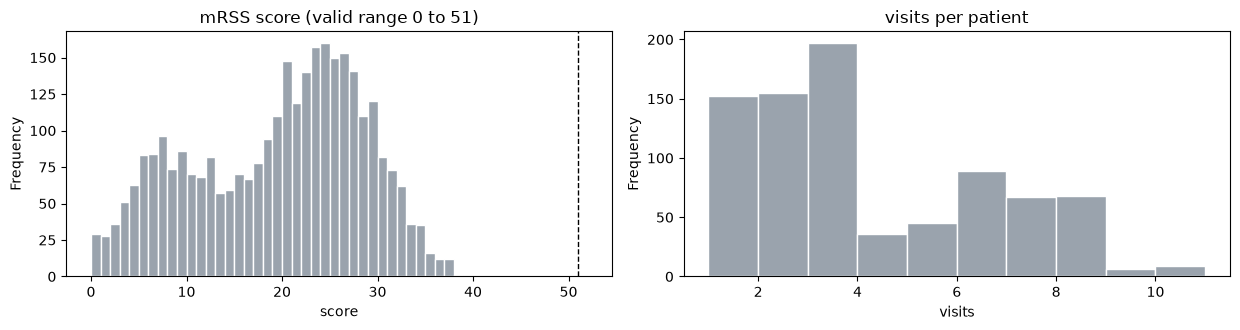

In [33]:
# Shape of the score, and how many visits patients have
fig, (ax_score, ax_visits) = plt.subplots(1, 2, figsize=(12.5, 3.4))
mrss["score"].plot.hist(bins=range(0, 53), ax=ax_score, color=GREY, edgecolor="white", title="mRSS score (valid range 0 to 51)")
ax_score.axvline(51, color="black", ls="--", lw=1)
ax_score.set_xlabel("score")
visits_per_patient.plot.hist(bins=range(1, visits_per_patient.max() + 2), ax=ax_visits, color=GREY, edgecolor="white", title="visits per patient")
ax_visits.set_xlabel("visits")
plt.tight_layout()

In [34]:
# One score per patient per day? Two scores on the same day cannot both be right
same_patient_same_day = mrss.duplicated(subset=["reg_id", "date"], keep=False)
display(checks_table([("exact duplicate rows", int(mrss.duplicated().sum())),
                      ("rows with the same patient and date", int(same_patient_same_day.sum()))]))
mrss[same_patient_same_day]

,check,result
0,exact duplicate rows,0
1,rows with the same patient and date,2


,reg_id,date,ENTRY_USER_NAME,mrss_score,score,rater
152,subject_2545,2020-01-15,Dr. Novak,20,20,Dr. Novak
153,subject_2545,2020-01-15,Dr. Novak,14,14,Dr. Novak


,check,result
0,raters,24
1,rows without a rater,0
2,"per-rater mean score, lowest to highest",7.7 to 25.8
3,cohort mean score,19.1


,n_visits,mean_score,pct_diffuse
rater,,,
Dr. Fischer,12,7.7,0.0
Dr. Wallace,13,13.1,38.0
Dr. Kline,12,14.6,25.0
Dr. Singh,51,14.9,49.0
Dr. Alvarez,7,17.3,43.0
Dr. Kim,130,17.6,59.0
Dr. Adler,456,18.2,60.0
Dr. Patel,596,18.6,66.0
Dr. Chen,256,18.9,64.0


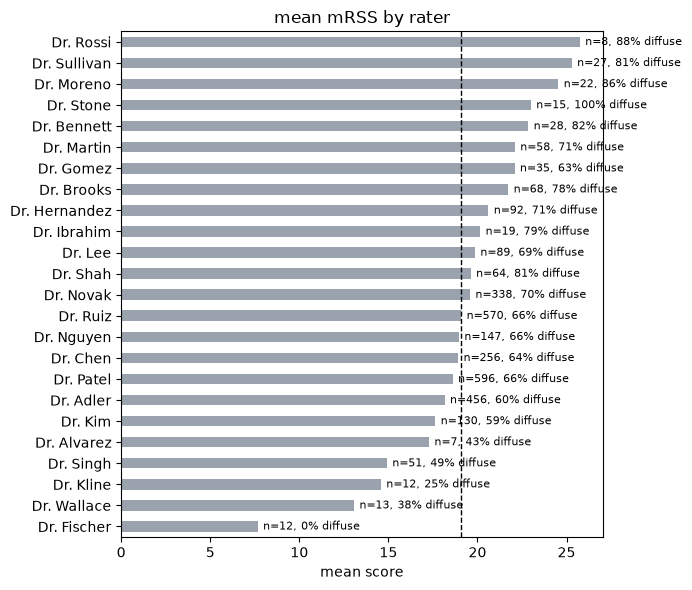

In [35]:
# Who scored, and does the score depend on who scored? mRSS is a hands-on exam, and inter-rater variability is a known weakness of the score
subtype = mrss["reg_id"].map(subtype_by_patient)                 # looked up from station 2
mrss = mrss.assign(subtype=subtype, is_diffuse=subtype == "dcSSc")
cohort_mean_score = mrss["score"].mean()
mrss_by_rater = (mrss.groupby("rater")
                     .agg(n_visits=("score", "size"), mean_score=("score", "mean"), share_diffuse=("is_diffuse", "mean"))
                     .sort_values("mean_score"))
mrss_by_rater["pct_diffuse"] = (mrss_by_rater["share_diffuse"] * 100).round(0)      # case mix: share of diffuse-type visits
display(checks_table([("raters", mrss["rater"].nunique()),
                      ("rows without a rater", int(mrss["rater"].isna().sum())),
                      ("per-rater mean score, lowest to highest", f"{mrss_by_rater['mean_score'].min():.1f} to {mrss_by_rater['mean_score'].max():.1f}"),
                      ("cohort mean score", round(cohort_mean_score, 1))]))
display(mrss_by_rater[["n_visits", "mean_score", "pct_diffuse"]].round(1))
ax = mrss_by_rater["mean_score"].plot.barh(figsize=(7, 6), color=GREY, title="mean mRSS by rater")
ax.axvline(cohort_mean_score, color="black", ls="--", lw=1)
for row, rater in enumerate(mrss_by_rater.itertuples()):
    ax.text(rater.mean_score + 0.3, row, f"n={rater.n_visits}, {rater.pct_diffuse:.0f}% diffuse", va="center", fontsize=8)
ax.set_xlabel("mean score")
ax.set_ylabel("")
plt.tight_layout()

In [36]:
# Is the rater spread a rater effect, or case mix? Compare raters within one subtype, keeping raters with at least 20 visits of that subtype
mean_score_by_subtype = mrss.groupby("subtype")["score"].mean()
mrss_by_subtype_and_rater = (mrss.groupby(["subtype", "rater"])["score"]
                                 .agg(n_visits="size", mean_score="mean")
                                 .query("n_visits >= 20"))
spread_within_subtype = (mrss_by_subtype_and_rater.groupby(level="subtype")["mean_score"]
                                                  .agg(raters="size", lowest_rater_mean="min", highest_rater_mean="max"))
spread_within_subtype["subtype_mean"] = mean_score_by_subtype
display(spread_within_subtype.round(1))
mrss_by_subtype_and_rater.round(1).sort_values(["subtype", "mean_score"])

,raters,lowest_rater_mean,highest_rater_mean,subtype_mean
subtype,,,,
dcSSc,16,22.5,29.5,24.4
lcSSc,10,7.1,9.5,8.9


n_visits  mean_score
subtype rater                              
dcSSc   Dr. Shah             52        22.5
        Dr. Singh            25        23.3
        Dr. Patel           391        23.7
        Dr. Kim              77        23.9
        Dr. Adler           272        24.2
        Dr. Novak           235        24.2
        Dr. Chen            163        24.3
        Dr. Ruiz            374        24.4
        Dr. Lee              61        25.1
        Dr. Nguyen           97        25.1
        Dr. Brooks           53        25.3
        Dr. Martin           41        25.9
        Dr. Hernandez        65        26.0
        Dr. Bennett          23        26.3
        Dr. Sullivan         22        29.2
        Dr. Gomez            22        29.5
lcSSc   Dr. Nguyen           50         7.1
        Dr. Singh            25         7.1
        Dr. Hernandez        27         7.7
        Dr. Kim              53         8.6
        Dr. Lee              27         8.8
        Dr. Patel           205         8.8
        Dr. Novak           103         9.0
        Dr. Ruiz            196         9.0
        Dr. Adler           184         9.2
        Dr. Chen             93         9.5

In [37]:
# Coherence with station 2: diffuse disease should have the higher skin score
mrss.groupby("subtype")["score"].describe()[["count", "25%", "50%", "75%"]].round(0).astype(int)

,count,25%,50%,75%
subtype,,,,
dcSSc,2040,21,24,28
lcSSc,1070,5,8,12


- 824 ids: the same three `SSC_NORM_*` controls as in vitals (issue 9 recurs) plus 821 registered patients.
- Scores are all numeric with no empties, 0 to 39 inside the valid 0 to 51; dates parse, 2014 to 2026; 1 to 10 visits per patient (median 3). Visit counts fall in two groups (1 to 3 and 6 to 8), a generator signature that needs no fix.
- The score histogram has two humps, near 7 and near 25, which are the two subtypes: limited median 8, diffuse median 24 once the station-2 subtype is looked up. Coherent with station 2.
- One patient has two scores on one day (`subject_2545`, 2020-01-15, Dr. Novak, 20 and 14). They cannot both be right and there is no basis to pick, so keep both and flag.
- 24 raters, per-rater mean 7.7 to 25.8. This looks like a large rater effect, but annotating each rater with the share of diffuse-type visits shows the spread follows case mix: Dr. Fischer (7.7) scored no diffuse patients, Dr. Rossi (25.8) 88%, Dr. Stone 100%. Within one subtype the spread collapses: diffuse 22.5 to 29.5 (16 raters; the two highest have 22 visits each), limited 7.1 to 9.5. There is no evidence of a rater problem beyond a few points. My first audit, now folded into `REPORT.md`, called this "rater heterogeneity" without adjusting for case mix; the report and the app's rater view carry the correction.

### Issue list after station 5

| # | table | what | why it matters | action |
|---|---|---|---|---|
| 20 | mrss | the same 3 `SSC_NORM_*` control ids as vitals | issue 9 recurs | quarantine |
| 21 | mrss | two scores for one patient on one day (`subject_2545`: 20 and 14) | they cannot both be right and there is no basis to pick | keep both + flag; never average them silently |
| 22 | docs / app (correction) | rater spread 7.7 to 25.8 is case mix (within-subtype spread 7.1 to 9.5 and 22.5 to 29.5) | the earlier draft reports a rater effect that is not there | correct the claim in the report and the rater view caption |

## Station 6: pft (pulmonary function lab; one row per measurement, long format)

Three measurements, all as % of the value predicted for a healthy person of the same age, sex and height (100 = exactly as expected, 80 = lower limit of normal):
FVC = forced vital capacity (how much air the lungs hold), FEV1 = volume blown out in the first second, DLCO = how well gas passes from lung into blood. Lung fibrosis lowers FVC and DLCO.

In [38]:
# Open pft: who is in it, and which measurements
pft = raw_tables["pft"]
display(checks_table([("rows", len(pft)), ("patients", pft["case_number"].nunique()),
                      ("of them registered in demographics", int(pft["case_number"].drop_duplicates().isin(registered_ids).sum())),
                      ("registered patients in demographics", len(registered_ids)),
                      ("ids not registered in demographics", ids_not_registered(pft, "case_number"))]))
display(pft[["NAME", "DESCRIPTION"]].value_counts().rename("rows").to_frame())
pft.head()

,check,result
0,rows,5069
1,patients,1174
2,of them registered in demographics,1171
3,registered patients in demographics,1500
4,ids not registered in demographics,"[SSC_NORM_0101, SSC_NORM_0102, SSC_NORM_0110]"


,,rows
NAME,DESCRIPTION,
FVC,Forced Vital Capacity (% predicted),1723
FEV1,Forced Expiratory Volume 1s (% predicted),1723
DLCO_SB,Diffusing Capacity CO single breath (% predicted),1623


,case_number,PFT_dts,DESCRIPTION,NAME,ORD_VALUE
0,subject_4646,2018-10-29,Forced Vital Capacity (% predicted),FVC,96.2
1,subject_4646,2018-10-29,Forced Expiratory Volume 1s (% predicted),FEV1,99.0
2,subject_4646,2018-10-29,Diffusing Capacity CO single breath (% predicted),DLCO_SB,123.5
3,subject_4646,2019-06-28,Forced Vital Capacity (% predicted),FVC,103.2
4,subject_4646,2019-06-28,Forced Expiratory Volume 1s (% predicted),FEV1,107.4


In [39]:
# Values and dates; per measurement, how much is missing and whether the range is plausible for a % predicted
pft_value_numeric = pd.to_numeric(pft["ORD_VALUE"], errors="coerce")
pft_date, n_unparseable_dates = parse_date_column(pft, "PFT_dts")
pft = pft.assign(value=pft_value_numeric, date=pft_date)
display(checks_table([("non-numeric values", int((pft["ORD_VALUE"].notna() & pft["value"].isna()).sum())),
                      ("unparseable dates", n_unparseable_dates),
                      ("date range", f"{pft['date'].min().date()} to {pft['date'].max().date()}")]))
value_range_by_measure = pft.groupby("NAME")["value"].agg(n="size", n_present="count", min="min", median="median", max="max")
value_range_by_measure.insert(2, "n_missing", value_range_by_measure["n"] - value_range_by_measure["n_present"])
value_range_by_measure.insert(3, "pct_missing", (100 * value_range_by_measure["n_missing"] / value_range_by_measure["n"]).round(1))
value_range_by_measure

,check,result
0,non-numeric values,0
1,unparseable dates,0
2,date range,2015-01-11 to 2025-12-26


,n,n_present,n_missing,pct_missing,min,median,max
NAME,,,,,,,
DLCO_SB,1623,829,794,48.9,40.0,76.1,130.0
FEV1,1723,1723,0,0.0,40.0,86.1,130.0
FVC,1723,1723,0,0.0,40.0,85.2,130.0


- 1,174 ids = 1,171 registered patients + the same three `SSC_NORM_*` controls (9 rows; issue 9 recurs).
- Three measurements, one description each, all "% predicted"; values numeric, dates parse, 2015 to 2025.
- All three run exactly 40 to 130: plausible for a % predicted, but the hard floor and ceiling look like generator bounds, and DLCO piles up at exactly 40. Clipped values; keep them and note it.
- DLCO is missing in 48.9% of its rows (794 of 1,623) while FVC and FEV1 are complete. DLCO needs a separate maneuver and is measured less often in practice. Keep it missing, without imputation, and show the missingness.

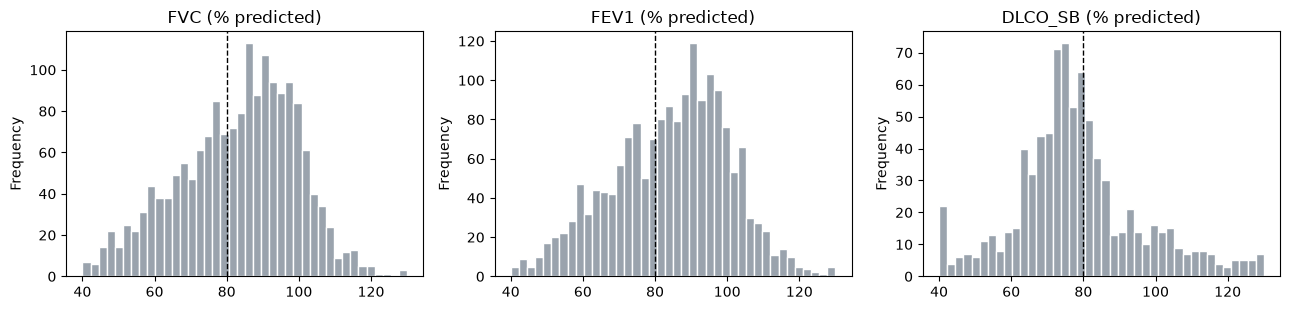

In [40]:
# Shape of each measurement; the dashed line is the lower limit of normal (80%)
fig, axes = plt.subplots(1, 3, figsize=(13, 3.2))
for ax, measure in zip(axes, ["FVC", "FEV1", "DLCO_SB"]):
    pft.loc[pft["NAME"] == measure, "value"].dropna().plot.hist(bins=40, ax=ax, color=GREY, edgecolor="white", title=f"{measure} (% predicted)")
    ax.axvline(80, color="black", ls="--", lw=1)
plt.tight_layout()

,check,result
0,visits with both FEV1 and FVC,1723
1,FEV1 above FVC,904
2,share of visits with FEV1 above FVC,52.5%
3,FEV1 / FVC median,1.003
4,FEV1 / FVC interquartile range,0.988 to 1.041
5,share of visits with a ratio below 0.90,0.1%
6,correlation of FVC and FEV1,0.977


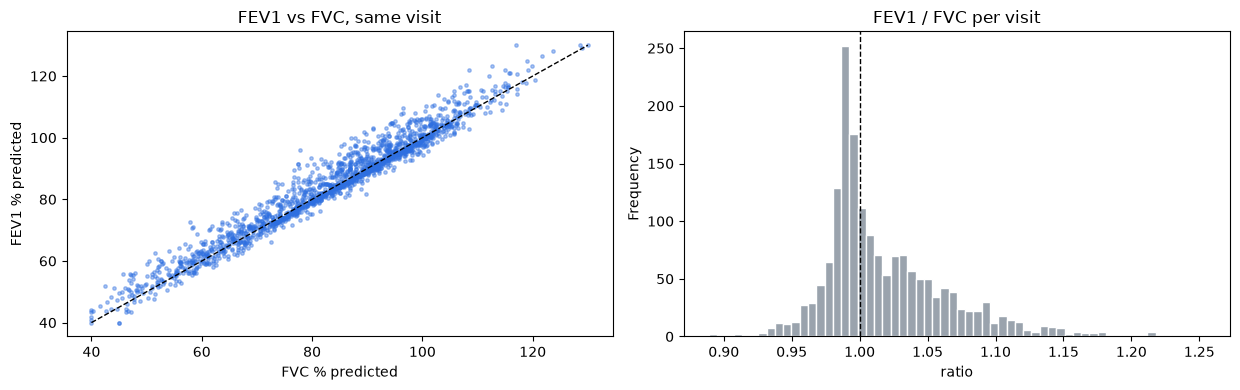

In [41]:
# One row per visit with one column per measurement, plus subtype, ILD and the FEV1/FVC ratio; FEV1 and FVC come from the same breath, so compare them visit by visit
pft_by_visit = pft.pivot_table(index=["case_number", "date"], columns="NAME", values="value", aggfunc="first").reset_index()
pft_by_visit = pft_by_visit.assign(subtype=pft_by_visit["case_number"].map(subtype_by_patient),
                                   ild=pft_by_visit["case_number"].map(ild_by_patient),
                                   fev1_fvc_ratio=pft_by_visit["FEV1"] / pft_by_visit["FVC"],
                                   fev1_above_fvc=pft_by_visit["FEV1"] > pft_by_visit["FVC"])
visits_with_fev1_and_fvc = pft_by_visit.dropna(subset=["FEV1", "FVC"])
fev1_fvc_ratio = visits_with_fev1_and_fvc["fev1_fvc_ratio"]
display(checks_table([
    ("visits with both FEV1 and FVC", len(visits_with_fev1_and_fvc)),
    ("FEV1 above FVC", int(visits_with_fev1_and_fvc["fev1_above_fvc"].sum())),
    ("share of visits with FEV1 above FVC", f"{visits_with_fev1_and_fvc['fev1_above_fvc'].mean():.1%}"),
    ("FEV1 / FVC median", round(fev1_fvc_ratio.median(), 3)),
    ("FEV1 / FVC interquartile range", f"{fev1_fvc_ratio.quantile(0.25):.3f} to {fev1_fvc_ratio.quantile(0.75):.3f}"),
    ("share of visits with a ratio below 0.90", f"{(fev1_fvc_ratio < 0.9).mean():.1%}"),
    ("correlation of FVC and FEV1", round(visits_with_fev1_and_fvc["FVC"].corr(visits_with_fev1_and_fvc["FEV1"]), 3)),
]))
fig, (ax_scatter, ax_hist) = plt.subplots(1, 2, figsize=(12.5, 4))
ax_scatter.scatter(visits_with_fev1_and_fvc["FVC"], visits_with_fev1_and_fvc["FEV1"], s=6, alpha=0.4, color=BLUE)
ax_scatter.plot([40, 130], [40, 130], color="black", ls="--", lw=1)      # the line where FEV1 equals FVC
ax_scatter.set_xlabel("FVC % predicted")
ax_scatter.set_ylabel("FEV1 % predicted")
ax_scatter.set_title("FEV1 vs FVC, same visit")
fev1_fvc_ratio.plot.hist(bins=60, ax=ax_hist, color=GREY, edgecolor="white", title="FEV1 / FVC per visit")
ax_hist.axvline(1, color="black", ls="--", lw=1)
ax_hist.set_xlabel("ratio")
plt.tight_layout()

percentile,0.01,0.05,0.10,0.25,0.50,0.75,0.90,0.95,0.99
FEV1 / FVC,0.939,0.964,0.976,0.988,1.003,1.041,1.082,1.108,1.167


,check,result
0,width of the middle 50%,0.053
1,minimum,0.889
2,maximum,1.254
3,healthy FEV1/FVC in liters (external benchmark),0.70 to 0.90 around a predicted 0.80
4,healthy band for the ratio of the two % predicted values,0.875 to 1.125


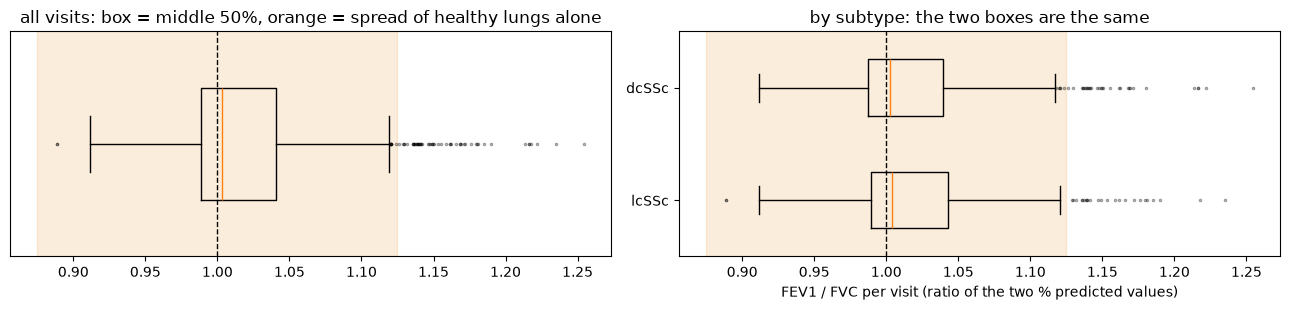

In [42]:
# The spread of the ratio in numbers and as a box plot, against the spread that healthy lungs alone would give
ratio_percentiles = fev1_fvc_ratio.quantile([0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]).round(3)
display(ratio_percentiles.rename("FEV1 / FVC").rename_axis("percentile").to_frame().T)
# external benchmark, not from this data: in liters, healthy FEV1/FVC runs about 0.70 to 0.90 around a predicted 0.80,
# so the ratio of the two % predicted values spreads over roughly 0.70/0.80 = 0.875 to 0.90/0.80 = 1.125 in healthy people
# alone, and wider once obstructive disease (asthma, COPD) is added
healthy_ratio_band = (0.70 / 0.80, 0.90 / 0.80)
display(checks_table([("width of the middle 50%", round(fev1_fvc_ratio.quantile(0.75) - fev1_fvc_ratio.quantile(0.25), 3)),
                      ("minimum", round(fev1_fvc_ratio.min(), 3)),
                      ("maximum", round(fev1_fvc_ratio.max(), 3)),
                      ("healthy FEV1/FVC in liters (external benchmark)", "0.70 to 0.90 around a predicted 0.80"),
                      ("healthy band for the ratio of the two % predicted values", f"{healthy_ratio_band[0]:.3f} to {healthy_ratio_band[1]:.3f}")]))

fig, (ax_all, ax_by_subtype) = plt.subplots(1, 2, figsize=(13, 3.2), sharex=True)
for ax in (ax_all, ax_by_subtype):
    ax.axvspan(*healthy_ratio_band, color=ORANGE, alpha=0.15)
    ax.axvline(1, color="black", ls="--", lw=1)
ax_all.boxplot(fev1_fvc_ratio, orientation="horizontal", widths=0.5, flierprops=dict(marker=".", markersize=3, alpha=0.4))
ax_all.set_yticks([])
ax_all.set_title("all visits: box = middle 50%, orange = spread of healthy lungs alone")
ratio_by_subtype = [visits_with_fev1_and_fvc.loc[visits_with_fev1_and_fvc["subtype"] == subtype, "fev1_fvc_ratio"] for subtype in ["lcSSc", "dcSSc"]]
ax_by_subtype.boxplot(ratio_by_subtype, orientation="horizontal", widths=0.5, tick_labels=["lcSSc", "dcSSc"], flierprops=dict(marker=".", markersize=3, alpha=0.4))
ax_by_subtype.set_title("by subtype: the two boxes are the same")
ax_by_subtype.set_xlabel("FEV1 / FVC per visit (ratio of the two % predicted values)")
plt.tight_layout()

- Same-visit pairs: 1,723; FEV1 above FVC in 904 (52.5%). In % predicted this is not impossible (the two percentages have different denominators, and in restrictive disease FEV1%pred at or above FVC%pred is common), so the count itself is not the finding; the shape is.
- The ratio is pinned: median 1.003, IQR 0.988 to 1.041, a spike just under 1.00; only 0.1% of visits fall below 0.90, where any cohort of about 1,200 older adults would show an obstructive tail (smokers, asthma, COPD); correlation 0.977 and the scatter is a narrow band on the diagonal. FEV1 behaves as FVC plus noise.
- In numbers: p1 0.939, p10 0.976, p25 0.988, p75 1.041, p90 1.082, p99 1.167; the middle 50% spans 0.053 and the whole cohort runs 0.889 to 1.254. Healthy variation in FEV1/FVC alone (0.70 to 0.90 in liters against a predicted 0.80) would spread this ratio over about 0.875 to 1.125 before any airway disease is added; here the box sits inside that band with nothing below it, and the limited and diffuse subtypes give the same box.

In [43]:
# Does the ratio carry any physiology? It should differ between disease types and with lung fibrosis, and be stable over the years of the registry
display(visits_with_fev1_and_fvc.groupby("subtype")["fev1_fvc_ratio"].median().round(3).rename("ratio median").to_frame())
display(visits_with_fev1_and_fvc.groupby("ild")["fev1_fvc_ratio"].median().round(3).rename("ratio median").rename_axis("ILD recorded").to_frame())
(visits_with_fev1_and_fvc.groupby(visits_with_fev1_and_fvc["date"].dt.year)["fev1_above_fvc"].mean().round(2)
                         .rename("share of visits with FEV1 above FVC").rename_axis("year").to_frame().T)

,ratio median
subtype,
dcSSc,1.003
lcSSc,1.004


,ratio median
ILD recorded,
False,1.003
True,1.004


year,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
share of visits with FEV1 above FVC,0.62,0.66,0.66,0.66,0.6,0.55,0.52,0.4,0.2,0.12,0.09


In [44]:
# Coherence with station 2: diffuse disease should show the lower lung values, and DLCO missingness should not differ much by subtype
pft = pft.assign(subtype=pft["case_number"].map(subtype_by_patient))
display(pft.groupby(["NAME", "subtype"])["value"].median().round(1).unstack("subtype").rename_axis(columns="median % predicted, by subtype"))
pft_dlco = pft[pft["NAME"] == "DLCO_SB"]
(pft_dlco["value"].isna().groupby(pft_dlco["subtype"]).mean() * 100).round(1).rename("DLCO missing, % of rows").to_frame()

"median % predicted, by subtype",dcSSc,lcSSc
NAME,,
DLCO_SB,73.6,78.4
FEV1,79.1,90.2
FVC,78.4,88.9


,"DLCO missing, % of rows"
subtype,
dcSSc,51.8
lcSSc,47.2


- The ratio adds no usable variation: median 1.003 vs 1.004 by subtype and 1.003 vs 1.004 by lung fibrosis. And the share of visits with FEV1 above FVC drifts from 62 to 66% (2015 to 2018) to 9% (2025), so the rule that generated FEV1 changed over the years and the column is unreliable everywhere.
- Decision: FEV1 and the FEV1/FVC ratio are excluded from analyses because in this dataset FEV1 tracks FVC and adds no usable variation (the values are possible, so they are not treated as errors); the 904 pairs are flagged and kept.
- Read against the subtypes from station 2: diffuse disease has the lower medians for FVC (78 vs 89), FEV1 (79 vs 90) and DLCO (74 vs 78). DLCO missingness is 51.8% diffuse vs 47.2% limited, no strong differential pattern.

### Issue list after station 6

| # | table | what | why it matters | action |
|---|---|---|---|---|
| 23 | pft | the same 3 `SSC_NORM_*` control ids (9 rows) | issue 9 recurs | quarantine |
| 24 | pft | DLCO missing 49% (794 of 1,623); FVC and FEV1 complete | DLCO needs a separate maneuver and is measured less often | keep missing, no imputation; display the missingness |
| 25 | pft | FEV1 tracks FVC: ratio at 1.00, no obstructive tail, no association with subtype or recorded fibrosis, pattern drifts by year | the column adds no usable variation in this dataset | FEV1 and FEV1/FVC left out of the analyses; the 904 FEV1 > FVC visits flagged and kept |
| 26 | pft | values bounded at exactly 40 and 130, DLCO piles up at 40 | generator clipping | keep, note in the dictionary |

## Station 7: medications (pharmacy; one row per prescription)

In [45]:
# Open medications: who is in it, and which drugs. Drug names are typed by people, so look for the same drug under several names
medications = raw_tables["medications"]
display(checks_table([("rows", len(medications)), ("patients", medications["reg_id"].nunique()),
                      ("of them registered in demographics", int(medications["reg_id"].drop_duplicates().isin(registered_ids).sum())),
                      ("registered patients in demographics", len(registered_ids)),
                      ("ids not registered in demographics", ids_not_registered(medications, "reg_id")),
                      ("distinct drug names", medications["medication"].nunique()),
                      ("rows without a drug name", int(medications["medication"].isna().sum())),
                      ("rows under the three names of mycophenolate (MEDICATION_ALIASES)",
                       int(medications["medication"].isin(set(MEDICATION_ALIASES) | set(MEDICATION_ALIASES.values())).sum()))]))
display(medications["medication"].value_counts().rename("rows").to_frame())
medications.head()

,check,result
0,rows,3273
1,patients,1327
2,of them registered in demographics,1327
3,registered patients in demographics,1500
4,ids not registered in demographics,[]
5,distinct drug names,16
6,rows without a drug name,20
7,rows under the three names of mycophenolate (MEDICATION_ALIASES),592


,rows
medication,
rituximab,253
naproxen,237
atorvastatin,224
omeprazole,221
calcium carbonate,220
amlodipine,215
mycophenolate mofetil,211
lisinopril,206
albuterol,202


,reg_id,date,medication,dose
0,subject_2005,2021-09-28,CellCept,1 g twice daily
1,subject_2005,2023-07-27,nifedipine,30 mg daily
2,subject_2009,2021-01-23,mycophenolate mofetil,1 g twice daily
3,subject_2009,2020-12-02,calcium carbonate,500 mg daily
4,subject_2021,2019-08-21,CellCept,1000 mg BID


In [46]:
# The dose column is free text, so list every distinct string and how often it occurs
display(checks_table([("distinct dose strings", medications["dose"].nunique()),
                      ("rows without a dose", int(medications["dose"].isna().sum()))]))
medications["dose"].value_counts().rename("rows").to_frame()

,check,result
0,distinct dose strings,23
1,rows without a dose,85


,rows
dose,
20 mg daily,437
500 mg BID,321
1000 mg IV x2,245
500 mg daily,212
5 mg daily,202
10 mg daily,197
PRN,196
30 mg daily,187
2000 IU daily,180


In [47]:
# Every impossible dose next to what the same drug usually gets in this table
# (the seven strings below are the ones that fail by reading the list above: zero, negative, absurd mass, mixed units)
impossible_doses = ["0 mg daily", "999 tablets daily", "-1 tablet daily", "250 g twice daily",
                    "10000 mg every hour", "500 mL tablets daily", "-25 mg daily"]


def most_common(strings):
    """The most frequent string in a column."""
    return strings.value_counts().index[0]


usual_dose_by_drug = medications[~medications["dose"].isin(impossible_doses)].groupby("medication")["dose"].agg(most_common)
impossible_dose_rows = medications[medications["dose"].isin(impossible_doses)].copy()
impossible_dose_rows["usual_dose_for_this_drug"] = impossible_dose_rows["medication"].map(usual_dose_by_drug)
display(checks_table([("rows with an impossible dose", len(impossible_dose_rows)),
                      ("drugs affected", impossible_dose_rows["medication"].nunique())]))
impossible_dose_rows[["reg_id", "medication", "dose", "usual_dose_for_this_drug"]].sort_values(["dose", "medication"]).reset_index(drop=True)

,check,result
0,rows with an impossible dose,45
1,drugs affected,15


,reg_id,medication,dose,usual_dose_for_this_drug
0,subject_6524,albuterol,-1 tablet daily,PRN
1,subject_2730,amlodipine,-1 tablet daily,5 mg daily
2,subject_5202,calcium carbonate,-1 tablet daily,500 mg daily
3,subject_8580,levothyroxine,-1 tablet daily,50 mcg daily
4,subject_6475,mycophenolate mofetil,-1 tablet daily,1500 mg BID
5,subject_4759,naproxen,-1 tablet daily,500 mg BID
6,subject_2651,rituximab,-1 tablet daily,1000 mg IV x2
7,subject_8391,amlodipine,-25 mg daily,5 mg daily
8,subject_2724,atorvastatin,-25 mg daily,20 mg daily
9,subject_2764,ibuprofen,-25 mg daily,400 mg PRN


- 1,327 of 1,500 patients have prescriptions; no control ids.
- 16 drug names, but `mycophenolate mofetil`, `CellCept` (brand) and `MMF` (abbreviation) are one drug: 592 rows under three names, to be mapped to one generic name. 20 rows have no drug name; keep the row (the date may still matter) but exclude it from drug counts.
- Dose is free text: 23 distinct strings, 85 empty. Sixteen are ordinary (`20 mg daily`, `1000 mg IV x2`, `PRN`); seven are impossible: `0 mg daily` (8), `999 tablets daily` (7), `-1 tablet daily` (7), `250 g twice daily` (7), `10000 mg every hour` (7), `500 mL tablets daily` (5), `-25 mg daily` (4). That is 45 rows of planted nonsense (zero, negative, absurd mass, mixed units). The current cleaning rule catches only `999 tablets daily` and must be widened.

In [48]:
# Dates and duplicates; and one generic name per drug (the three spellings of mycophenolate from the list above), used from here on
medications_date, n_unparseable_dates = parse_date_column(medications, "date")
medications = medications.assign(date=medications_date, medication_generic=medications["medication"].replace(MEDICATION_ALIASES))
display(checks_table([("unparseable dates", n_unparseable_dates),
                      ("date range", f"{medications['date'].min().date()} to {medications['date'].max().date()}"),
                      ("exact duplicate rows", int(medications.duplicated().sum())),
                      ("rows with the same patient, date and drug more than once", int(medications.duplicated(subset=["reg_id", "date", "medication"], keep=False).sum()))]))
medications.groupby("reg_id").size().describe().round(1).rename("prescriptions per patient").to_frame()

,check,result
0,unparseable dates,0
1,date range,2015-04-23 to 2025-07-28
2,exact duplicate rows,0
3,"rows with the same patient, date and drug more than once",0


,prescriptions per patient
count,1327.0
mean,2.5
std,1.1
min,1.0
25%,2.0
50%,2.0
75%,3.0
max,6.0


In [49]:
# Cross-check with station 2: a prescription dated before the diagnosis is fine for general drugs
# (nifedipine for Raynaud's is given years before anyone says "SSc") and not for SSc-specific immunosuppressants
medications = medications.assign(diagnosis_date=medications["reg_id"].map(diagnosis_date_by_patient))
prescriptions_before_diagnosis = medications[medications["date"] < medications["diagnosis_date"]]
ssc_specific_drugs = ["mycophenolate mofetil", "rituximab", "tocilizumab"]      # disease-modifying drugs, given only after the diagnosis
ssc_specific_before_diagnosis = prescriptions_before_diagnosis[prescriptions_before_diagnosis["medication_generic"].isin(ssc_specific_drugs)].copy()
ssc_specific_before_diagnosis["days_before_diagnosis"] = (ssc_specific_before_diagnosis["diagnosis_date"] - ssc_specific_before_diagnosis["date"]).dt.days
display(checks_table([("prescriptions dated before the diagnosis", len(prescriptions_before_diagnosis)),
                      ("patients", prescriptions_before_diagnosis["reg_id"].nunique()),
                      ("of them SSc-specific immunosuppressants", len(ssc_specific_before_diagnosis))]))
display(prescriptions_before_diagnosis["medication"].value_counts().rename("rows").to_frame())
ssc_specific_before_diagnosis[["reg_id", "date", "diagnosis_date", "days_before_diagnosis", "medication", "dose"]].sort_values("days_before_diagnosis")

,check,result
0,prescriptions dated before the diagnosis,70
1,patients,66
2,of them SSc-specific immunosuppressants,14


,rows
medication,
vitamin D3,8
amlodipine,7
naproxen,7
lisinopril,6
levothyroxine,6
nifedipine,5
calcium carbonate,4
CellCept,4
albuterol,4


,reg_id,date,diagnosis_date,days_before_diagnosis,medication,dose
2337,subject_7048,2019-01-09,2019-01-14,5,CellCept,1500 mg BID
1780,subject_5915,2019-12-11,2019-12-26,15,rituximab,1000 mg IV x2
1956,subject_6240,2021-05-24,2021-06-14,21,MMF,750mg BID
2852,subject_8147,2021-04-18,2021-05-10,22,MMF,750mg BID
1745,subject_5833,2016-05-01,2016-05-31,30,mycophenolate mofetil,750mg BID
1700,subject_5705,2017-04-10,2017-05-12,32,CellCept,1000 mg BID
2876,subject_8182,2016-03-01,2016-04-02,32,rituximab,1000 mg IV x2
1263,subject_4822,2020-11-23,2020-12-26,33,mycophenolate mofetil,1000 mg BID
3017,subject_8435,2020-11-05,2020-12-20,45,MMF,1500 mg BID
424,subject_2977,2017-11-03,2017-12-20,47,tocilizumab,162 mg SC weekly


In [50]:
# Coherence with station 2: immunosuppressants should concentrate in diffuse disease and in patients with lung fibrosis
medications = medications.assign(subtype=medications["reg_id"].map(subtype_by_patient), ild=medications["reg_id"].map(ild_by_patient))
top_drugs = medications["medication_generic"].value_counts().head(8).index
is_top_drug = medications["medication_generic"].isin(top_drugs)
drug_share_by_subtype = (pd.crosstab(medications.loc[is_top_drug, "medication_generic"], medications.loc[is_top_drug, "subtype"], normalize="columns") * 100).round(0).astype(int)
drug_share_by_subtype["ILD %"] = (medications[is_top_drug].groupby("medication_generic")["ild"].mean() * 100).round(0).astype(int)
drug_share_by_subtype     # first two columns: % of each subtype's prescriptions that are this drug; last column: % of the drug's prescriptions in patients with lung fibrosis

subtype,dcSSc,lcSSc,ILD %
medication_generic,,,
amlodipine,10,10,43
atorvastatin,9,11,46
calcium carbonate,8,12,35
lisinopril,8,11,44
mycophenolate mofetil,31,24,73
naproxen,10,11,42
omeprazole,9,11,47
rituximab,15,9,57


- Dates parse, 2015 to 2025; no duplicates; 1 to 6 prescriptions per patient.
- 70 prescriptions (66 patients) are dated before the diagnosis. For general drugs that is normal: nifedipine and amlodipine for Raynaud's, statins, thyroid hormone, antacids are given long before anyone says "SSc". For the 14 SSc-specific immunosuppressants (mycophenolate under its three names, rituximab, tocilizumab) it is not; they are started only once the diagnosis exists. All 14 fall 5 to 80 days before the recorded diagnosis date. The likeliest story is that treatment started at the diagnosing visit and the diagnosis date was entered later; this export carries nothing that would confirm it, so flag and do not move any date.
- Set against the subtypes from station 2: mycophenolate is 31% of diffuse-type prescriptions vs 24% of limited-type, and 73% of its prescriptions go to patients with lung fibrosis while general drugs sit at 42 to 47%; rituximab 15% vs 9%, 57% fibrosis. The immunosuppressants land where the lung disease is.

### Issue list after station 7

| # | table | what | why it matters | action |
|---|---|---|---|---|
| 27 | medications | one drug under three names (`mycophenolate mofetil`, `CellCept`, `MMF`; 592 rows) | any drug count is split three ways | map to one generic name |
| 28 | medications | 20 rows without a drug name, 85 without a dose | the rows still carry a date that may matter | keep the rows; exclude from drug-level counts |
| 29 | medications | 45 rows with impossible doses (zero, negative, 999 tablets, 250 g, 10000 mg every hour, mL tablets) | the pipeline currently catches only `999 tablets daily` (7 rows) | dose set to missing + logged; widen the rule |
| 30 | medications | 14 SSc-specific immunosuppressant prescriptions dated 5 to 80 days before the diagnosis | likely the diagnosis date was entered after treatment started | flag only |

## Station 8: bal (bronchoscopy suite; one row per lavage procedure)

BAL = bronchoalveolar lavage: a bronchoscope is passed into one lung segment, sterile saline is instilled and suctioned back. The fluid carries the cells living in the air sacs (mostly alveolar macrophages); those cells go on to station 9 (RNA-seq libraries). Not all the saline comes back: 40 to 70% recovery is typical.

In [51]:
# Open bal: who is in it, and is each procedure identified once
bal = raw_tables["bal"]
display(checks_table([("procedures", len(bal)), ("patients", bal["reg_id"].nunique()),
                      ("of them registered in demographics", int(bal["reg_id"].drop_duplicates().isin(registered_ids).sum())),
                      ("registered patients in demographics", len(registered_ids)),
                      ("ids not registered in demographics", ids_not_registered(bal, "reg_id")),
                      ("bal_id unique", bal["bal_id"].is_unique)]))
display(bal.groupby("reg_id").size().value_counts().sort_index().rename("patients").rename_axis("procedures per patient").to_frame())
bal.head()

,check,result
0,procedures,1170
1,patients,820
2,of them registered in demographics,820
3,registered patients in demographics,1500
4,ids not registered in demographics,[]
5,bal_id unique,True


,patients
procedures per patient,
1,522
2,246
3,52


,bal_id,reg_id,procedure_date,procedure_site,volume_instilled_ml,volume_recovered_ml,bal_comment
0,BAL_2005-880,subject_2005,2021-10-10,Lingula,120,58.2,NaN
1,BAL_2009-529,subject_2009,2020-01-21,Left lower lobe,100,44.0,All 7 mL of sample were processed - cell count was too low to sort
2,BAL_2028-696,subject_2028,2017-02-23,Lingula,100,41.1,"Bloody tinge initially, cleared with subsequent aliquots"
3,BAL_2028-580,subject_2028,2017-08-29,Right lower lobe,120,59.3,Sample extremely viscous; was diluted with MACs buffer prior to filtering (no supernatant sample collected)
4,BAL_2053-324,subject_2053,2021-03-21,Left lower lobe,120,54.8,"Low return volume, procedure tolerated well"


In [52]:
# The categorical columns: where the lavage was done, and the comment
display(bal["procedure_site"].value_counts(dropna=False).rename("rows").to_frame())
display(checks_table([("rows with a comment", f"{bal['bal_comment'].notna().mean():.0%}"),
                      ("distinct comments", bal["bal_comment"].nunique())]))
bal["bal_comment"].value_counts().head(6).rename("rows").to_frame()

,rows
procedure_site,
Lingula,241
Right upper lobe,241
Left lower lobe,235
Right middle lobe,235
Right lower lobe,218


,check,result
0,rows with a comment,68%
1,distinct comments,6


,rows
bal_comment,
Sample extremely-mucous like; small yield in cells and insufficient amount to sort,159
Cloudy return; moderate mucus burden,133
Sample extremely viscous; was diluted with MACs buffer prior to filtering (no supernatant sample collected),132
"Bloody tinge initially, cleared with subsequent aliquots",129
"Low return volume, procedure tolerated well",125
All 7 mL of sample were processed - cell count was too low to sort,120


,count,mean,std,min,25%,50%,75%,max
volume_instilled_ml,1170.0,96.8,14.4,80.0,80.0,90.0,100.0,120.0
volume_recovered_ml,1170.0,40.2,13.5,8.0,30.8,40.2,49.4,78.8


,procedures
instilled volume (mL),
80,297
90,299
100,312
120,262


,check,result
0,recovered above instilled (impossible),0
1,recovery fraction median,0.41
2,recovery fraction range,0.08 to 0.81


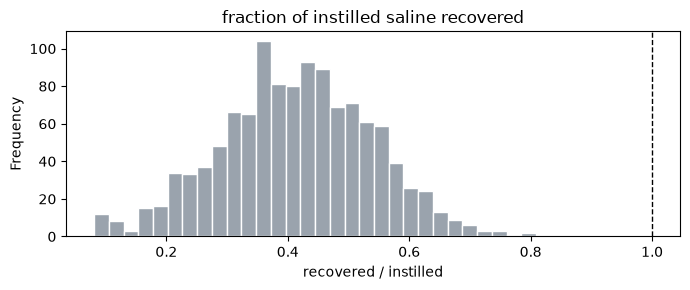

In [53]:
# The volumes: what went in, what came back, and the physical rule that recovered cannot exceed instilled
recovery_fraction = bal["volume_recovered_ml"] / bal["volume_instilled_ml"]
display(bal[["volume_instilled_ml", "volume_recovered_ml"]].describe().round(1).T)
display(bal["volume_instilled_ml"].value_counts().sort_index().rename("procedures").rename_axis("instilled volume (mL)").to_frame())
display(checks_table([("recovered above instilled (impossible)", int((bal["volume_recovered_ml"] > bal["volume_instilled_ml"]).sum())),
                      ("recovery fraction median", round(recovery_fraction.median(), 2)),
                      ("recovery fraction range", f"{recovery_fraction.min():.2f} to {recovery_fraction.max():.2f}")]))
fig, ax = plt.subplots(figsize=(7, 3))
recovery_fraction.plot.hist(bins=30, ax=ax, color=GREY, edgecolor="white", title="fraction of instilled saline recovered")
ax.axvline(1, color="black", ls="--", lw=1)
ax.set_xlabel("recovered / instilled")
plt.tight_layout()

In [54]:
# Dates, duplicates, and the cross-check with station 2: a research bronchoscopy before the diagnosis date?
bal_date, n_unparseable_dates = parse_date_column(bal, "procedure_date")
bal = bal.assign(date=bal_date, diagnosis_date=bal["reg_id"].map(diagnosis_date_by_patient))
days_before_diagnosis = (bal["diagnosis_date"] - bal["date"]).dt.days
procedure_before_diagnosis = days_before_diagnosis > 0
checks_table([("unparseable dates", n_unparseable_dates),
              ("date range", f"{bal['date'].min().date()} to {bal['date'].max().date()}"),
              ("rows with the same patient and date twice", int(bal.duplicated(subset=["reg_id", "date"], keep=False).sum())),
              ("procedures dated before the diagnosis", int(procedure_before_diagnosis.sum())),
              ("share of procedures", f"{procedure_before_diagnosis.mean():.0%}"),
              ("days before the diagnosis: min / median / max",
               f"{days_before_diagnosis[procedure_before_diagnosis].min():.0f} / {days_before_diagnosis[procedure_before_diagnosis].median():.0f} / {days_before_diagnosis[procedure_before_diagnosis].max():.0f}"),
              ("longest lead before the diagnosis (years)", f"{days_before_diagnosis[procedure_before_diagnosis].max() / 365.25:.1f}")])

,check,result
0,unparseable dates,0
1,date range,2016-01-01 to 2025-12-14
2,rows with the same patient and date twice,0
3,procedures dated before the diagnosis,104
4,share of procedures,9%
5,days before the diagnosis: min / median / max,1 / 79 / 1196
6,longest lead before the diagnosis (years),3.3


In [55]:
# Coherence with station 2: research bronchoscopy targets lung disease, so BAL patients should be enriched for fibrosis and diffuse disease
bal_patients = pd.Index(bal["reg_id"].unique())
checks_table([
    ("lung fibrosis recorded, BAL patients", f"{ild_by_patient.reindex(bal_patients).mean():.0%}"),
    ("lung fibrosis recorded, whole cohort", f"{ild_by_patient.mean():.0%}"),
    ("diffuse subtype, BAL patients", f"{(subtype_by_patient.reindex(bal_patients) == 'dcSSc').mean():.0%}"),
    ("diffuse subtype, whole cohort", f"{(subtype_by_patient == 'dcSSc').mean():.0%}"),
])

,check,result
0,"lung fibrosis recorded, BAL patients",56%
1,"lung fibrosis recorded, whole cohort",42%
2,"diffuse subtype, BAL patients",62%
3,"diffuse subtype, whole cohort",40%


- 1,170 procedures on 820 patients (1 to 3 each); `bal_id` unique; no control ids.
- Five lavage sites with almost equal counts (218 to 241). Real practice favors the lingula and right middle lobe, so the flat split is a generator signature and needs no fix.
- The comment column is a pick-list: 68% of rows carry one of 6 fixed sentences (mucus, viscous sample, bloody tinge, low return, too few cells to sort). They describe sample quality. The libraries table at station 9 has a comment column of its own, which is the lab's note and does not repeat these sentences; the two tables link on patient and date.
- Volumes are physically consistent: instilled is one of 80 / 90 / 100 / 120 mL, recovered 8 to 79 mL, and recovered never exceeds instilled (0 of 1,170); recovery fraction median 0.41, range 0.08 to 0.81. This is the positive finding of this station.
- Dates parse, 2016 to 2025; no patient has two procedures on one day.
- 104 procedures (9%) are dated before the diagnosis, 1 to 1,196 days earlier (median 79). Unlike the medication case (all within 80 days), a tail of up to three years cannot be a data-entry lag. Flag as a timeline inconsistency; no fix is possible.
- Compared with station 2: BAL patients are enriched for lung fibrosis (56% vs 42% in the whole cohort) and diffuse disease (62% vs 40%), so the research procedure went to the patients it should.

### Issue list after station 8

| # | table | what | why it matters | action |
|---|---|---|---|---|
| 31 | bal | 104 procedures (9%) dated before the diagnosis, up to 3.3 years earlier | timeline inconsistency; too far for an entry lag | flag; no fix possible |
| 32 | bal | comment is a 6-item pick-list, site counts flat across 5 sites | neither is an error; the comment describes sample quality and does not reappear in the libraries table | document |

## Station 9: libraries (wet lab; one row per sample, from RNA extraction through QC and library prep to sequencing)

The cells recovered at station 8 go to the lab: cell viability is checked, RNA is extracted (kit, lot, tube, freezer box), its quality is measured on a TapeStation (RIN = RNA integrity number, 1 to 10, higher means more intact; concentration in pg/µl), and good samples are made into sequencing libraries and grouped into batches. This is a LIMS export, so it reads like a lab notebook.

In [56]:
# Open libraries; the column names themselves are the first finding (spaces, units, question marks)
libraries = raw_tables["libraries"]
display(checks_table([("rows", len(libraries)), ("patients", libraries["reg_id"].nunique()),
                      ("of them registered in demographics", int(libraries["reg_id"].drop_duplicates().isin(registered_ids).sum())),
                      ("registered patients in demographics", len(registered_ids)),
                      ("ids not registered in demographics", ids_not_registered(libraries, "reg_id")),
                      ("of them not seen at earlier stations", sorted(set(ids_not_registered(libraries, "reg_id")) - control_ids))]))
pd.DataFrame({"column": libraries.columns})

,check,result
0,rows,918
1,patients,702
2,of them registered in demographics,698
3,registered patients in demographics,1500
4,ids not registered in demographics,"[SSC_NORM_0101, SSC_NORM_0102, SSC_NORM_0104, SSC_NORM_0110]"
5,of them not seen at earlier stations,[SSC_NORM_0104]


,column
0,reg_id
1,cell_viability
2,processing_date
3,comment
4,RNA isolation kit
5,Kit lot number
6,Elution vol (ul)
7,Macrophage RNA Tube ID
8,Macrophage RNA Tube Location Box ID
9,Date of RNA QC


In [57]:
# How full each column is (read top to bottom: the lab steps in order, and where samples drop out); then the date and the three quality numbers parsed
fill_rate_pct = (libraries.notna().mean() * 100).round(0).astype(int).rename("filled, % of rows").to_frame()
display(fill_rate_pct)
processing_date, n_unparseable_dates = parse_date_column(libraries, "processing_date")
libraries = libraries.assign(processing_date=processing_date,
                             cell_viability_pct=pd.to_numeric(libraries["cell_viability"], errors="coerce"),
                             rin=pd.to_numeric(libraries["RIN"], errors="coerce"),
                             rna_concentration_pg_ul=pd.to_numeric(libraries["RNA concentration (pg/ul)"], errors="coerce"))
display(checks_table([("unparseable processing dates", n_unparseable_dates)]))
libraries.head(3)

,"filled, % of rows"
reg_id,100
cell_viability,92
processing_date,41
comment,19
RNA isolation kit,30
Kit lot number,30
Elution vol (ul),30
Macrophage RNA Tube ID,27
Macrophage RNA Tube Location Box ID,27
Date of RNA QC,21


,check,result
0,unparseable processing dates,0


,reg_id,cell_viability,processing_date,comment,RNA isolation kit,Kit lot number,Elution vol (ul),Macrophage RNA Tube ID,Macrophage RNA Tube Location Box ID,Date of RNA QC,RNA volume for QC,RIN,RNA concentration (pg/ul),TS comment,TechCore comment,Sequence?,TapeStation assay type,ul for 250 pg,Complete?,Library prep date,Sample,RNA Tube ID,Library prep plate,RNAseq batch,cell_viability_pct,rin,rna_concentration_pg_ul
0,subject_3975,99.0,2018-02-11,"Low concentration, almost no 18S and 28S peaks. Use for sequencing (serial sample).",Norgen Single Cell RNA kit,161004778.0,16.0,303871963.0,TS01069817,2018-02-12,1.0,NaN,895.0,RNA concentration outside recommended range for RINe; RINe edited,"Low concentration, almost no 18S and 28S peaks. Use for sequencing (serial sample).",Yes,Pico RNA,6.24,Complete,2018-03-18,3975-SMP-03,303871963.0,G1,SCRIPT_RNAseq_Batch_03,99.0,NaN,895.0
1,subject_8264,42.9,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,42.9,NaN,NaN
2,subject_5895,52.3,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5895-SMP-05,NaN,NaN,NaN,52.3,NaN,NaN


- 918 rows on 702 ids, four of them `SSC_NORM_*` controls (5 rows); `SSC_NORM_0104` appears in no other table.
- The 24 column names carry spaces, units in brackets and question marks (`Elution vol (ul)`, `Sequence?`, `Complete?`). Rename them to snake_case in cleaning; nothing else can be typed reliably against them.
- The fill rates read like the lab's workflow: `cell_viability` 92% (every sample gets a viability check), `processing_date` 41%, kit and tube fields 30%, QC fields 21%, `RIN` 14%, library and batch fields 21%. Most rows are sample slots that never went past the viability check; the table is a funnel, not a per-patient record.

In [58]:
# The funnel, step by step: how many samples reach each stage
funnel_steps = {
    "sample processed (processing_date)": libraries["processing_date"].notna(),
    "RNA quality checked (Date of RNA QC)": libraries["Date of RNA QC"].notna(),
    "RIN recorded": libraries["rin"].notna(),
    "marked Sequence? = Yes": libraries["Sequence?"].eq("Yes"),
    "library prepared (Library prep date)": libraries["Library prep date"].notna(),
    "marked Complete? = Complete": libraries["Complete?"].eq("Complete"),
    "assigned to a sequencing batch": libraries["RNAseq batch"].notna(),
}
pd.DataFrame({"samples": {step: int(reached.sum()) for step, reached in funnel_steps.items()}}).rename_axis("step")

,samples
step,
sample processed (processing_date),372
RNA quality checked (Date of RNA QC),193
RIN recorded,132
marked Sequence? = Yes,188
library prepared (Library prep date),192
marked Complete? = Complete,134
assigned to a sequencing batch,192


In [59]:
# The two status flags against each other: a sample cannot be "not for sequencing" and "complete" at the same time
sequence_flag = libraries["Sequence?"].fillna("(not decided)").rename("Sequence?")
complete_flag = libraries["Complete?"].fillna("(not started)").rename("Complete?")
status_crosstab = (pd.crosstab(sequence_flag, complete_flag, margins=True, margins_name="total")
                     .reindex(index=["(not decided)", "No", "Yes", "total"],
                              columns=["(not started)", "Partial", "Complete", "total"]))     # rows: the decision; columns: the progress
contradiction = libraries["Sequence?"].eq("No") & libraries["Complete?"].isin(["Partial", "Complete"])
display(checks_table([("marked No for sequencing, yet library work recorded (highlighted in red)", int(contradiction.sum()))]))
status_crosstab.style.map(red_if_nonzero, subset=pd.IndexSlice[["No"], ["Partial", "Complete"]])

,check,result
0,"marked No for sequencing, yet library work recorded (highlighted in red)",23


Complete?,(not started),Partial,Complete,total
Sequence?,,,,
(not decided),648,0,0,648
No,59,10,13,82
Yes,19,48,121,188
total,726,58,134,918


In [60]:
# The quality numbers, and the RIN gap: sequenced samples without a RIN, and what the TapeStation comment says about them
quality_columns = ["cell_viability_pct", "rin", "rna_concentration_pg_ul"]
display(libraries[quality_columns].describe().loc[["count", "min", "50%", "max"]].round(1).T)
libraries_sequenced = libraries[libraries["Sequence?"].eq("Yes")]
sequenced_without_rin = libraries_sequenced[libraries_sequenced["rin"].isna()]
sequenced_with_rin = libraries_sequenced[libraries_sequenced["rin"].notna()]
display(checks_table([
    ("samples marked Sequence? = Yes", len(libraries_sequenced)),
    ("of them without a RIN", len(sequenced_without_rin)),
    ("of those, with a QC date", int(sequenced_without_rin["Date of RNA QC"].notna().sum())),
    ("of those, with a concentration", int(sequenced_without_rin["rna_concentration_pg_ul"].notna().sum())),
    ("RNA concentration median, sequenced without RIN", round(sequenced_without_rin["rna_concentration_pg_ul"].median())),
    ("RNA concentration median, sequenced with RIN", round(sequenced_with_rin["rna_concentration_pg_ul"].median())),
]))
display(sequenced_without_rin["TS comment"].fillna("(empty)").value_counts().rename("sequenced samples without RIN").to_frame())
sequenced_with_rin["TS comment"].fillna("(empty)").value_counts().rename("sequenced samples with RIN").to_frame()

,count,min,50%,max
cell_viability_pct,840.0,7.3,62.3,99.0
rin,132.0,5.5,7.8,9.8
rna_concentration_pg_ul,232.0,16.8,737.6,49785.4


,check,result
0,samples marked Sequence? = Yes,188
1,of them without a RIN,88
2,"of those, with a QC date",88
3,"of those, with a concentration",88
4,"RNA concentration median, sequenced without RIN",578
5,"RNA concentration median, sequenced with RIN",910


,sequenced samples without RIN
TS comment,
RNA concentration outside recommended range for RINe,28
RNA concentration outside recommended range for RINe; RINe edited,22
ok,21
(empty),17


,sequenced samples with RIN
TS comment,
(empty),38
RNA concentration outside recommended range for RINe; RINe edited,25
RNA concentration outside recommended range for RINe,23
ok,13
Slightly broad 18S peak.,1


In [61]:
# Identifiers and batches: sample ids must be unique, and a sequencing batch of one sample is suspicious
sample_ids = libraries["Sample"].dropna()
duplicated_sample_ids = sorted(sample_ids[sample_ids.duplicated(keep=False)].unique())
samples_per_batch = libraries["RNAseq batch"].value_counts().sort_index()
display(checks_table([("sample ids", len(sample_ids)), ("distinct", sample_ids.nunique()),
                      ("used more than once", duplicated_sample_ids), ("batches", len(samples_per_batch))]))
display(libraries.loc[libraries["Sample"].isin(duplicated_sample_ids), ["reg_id", "Sample", "processing_date", "Library prep date", "RNAseq batch"]].sort_values("Sample"))
samples_per_batch.rename("samples").rename_axis("batch").to_frame()

,check,result
0,sample ids,307
1,distinct,303
2,used more than once,"[4560-SMP-00, 4582-SMP-08, 6580-SMP-02, 6802-SMP-04]"
3,batches,8


,reg_id,Sample,processing_date,Library prep date,RNAseq batch
405,subject_4560,4560-SMP-00,2020-10-07,2020-10-18,SCRIPT_RNAseq_Batch_01
782,subject_4560,4560-SMP-00,2021-03-18,2021-04-14,SCRIPT_RNAseq_Batch_04
417,subject_4582,4582-SMP-08,2021-10-24,2021-11-03,SCRIPT_RNAseq_Batch_04
860,subject_4582,4582-SMP-08,NaT,NaN,NaN
435,subject_6580,6580-SMP-02,NaT,NaN,NaN
565,subject_6580,6580-SMP-02,NaT,NaN,NaN
184,subject_6802,6802-SMP-04,2016-03-23,NaN,NaN
310,subject_6802,6802-SMP-04,2016-10-21,2016-11-17,SCRIPT_RNAseq_Batch_03


,samples
batch,
SCRIPT_RNAseq_Batch_01,49
SCRIPT_RNAseq_Batch_02,46
SCRIPT_RNAseq_Batch_03,39
SCRIPT_RNAseq_Batch_04,54
SCRIPT_RNAseq_Batch_09,1
SCRIPT_RNAseq_Batch_10,1
SCRIPT_RNAseq_Batch_12,1
SCRIPT_RNAseq_Batch_15,1


In [62]:
# Link back to station 8: every processed sample should come from a lavage of the same patient a few days earlier
libraries_with_row_id = libraries.rename_axis("library_row").reset_index()                      # keep the library row id through the merge
library_to_lavage = libraries_with_row_id.merge(bal[["reg_id", "date", "bal_comment"]].rename(columns={"date": "lavage_date"}),
                                                on="reg_id", how="left")                          # every lavage of the same patient
library_to_lavage["days_after_lavage"] = (library_to_lavage["processing_date"] - library_to_lavage["lavage_date"]).dt.days
library_to_lavage["days_after_lavage"] = library_to_lavage["days_after_lavage"].where(library_to_lavage["days_after_lavage"] >= 0)   # processing cannot precede the lavage
nearest_lavage = library_to_lavage.sort_values("days_after_lavage").drop_duplicates("library_row")   # the closest preceding lavage per library row
processed_samples = nearest_lavage[nearest_lavage["processing_date"].notna()]
processed_with_comment = processed_samples[processed_samples["comment"].notna()]
display(checks_table([
    ("processed samples", len(processed_samples)),
    ("with a lavage of the same patient on or before processing", int(processed_samples["days_after_lavage"].notna().sum())),
    ("processed samples with a comment", len(processed_with_comment)),
    ("comment identical to the lavage comment", int((processed_with_comment["comment"] == processed_with_comment["bal_comment"]).sum())),
]))
display(processed_samples["days_after_lavage"].value_counts().sort_index().rename("samples").rename_axis("days from lavage to processing").to_frame())
processed_with_comment[["comment", "bal_comment"]].head(3)

,check,result
0,processed samples,372
1,with a lavage of the same patient on or before processing,367
2,processed samples with a comment,121
3,comment identical to the lavage comment,7


,samples
days from lavage to processing,
0.0,1
1.0,96
2.0,104
3.0,87
4.0,79


,comment,bal_comment
1537,Sample extremely-mucous like; small yield in cells and insufficient amount to sort,Sample extremely viscous; was diluted with MACs buffer prior to filtering (no supernatant sample collected)
415,"Low concentration, almost no 18S and 28S peaks. Use for sequencing (serial sample).",Cloudy return; moderate mucus burden
254,All 7 mL of sample were processed - cell count was too low to sort,NaN


In [63]:
# Rows per patient in libraries against lavages per patient in bal
library_and_lavage_counts = pd.DataFrame({"library_rows": libraries.groupby("reg_id").size(),
                                          "bal_procedures": bal.groupby("reg_id").size()}).fillna(0).astype(int)
more_libraries_than_lavages = library_and_lavage_counts[library_and_lavage_counts["library_rows"] > library_and_lavage_counts["bal_procedures"]]
checks_table([("patients with more library rows than lavages", len(more_libraries_than_lavages)),
              ("who they are", more_libraries_than_lavages.index.tolist())])

,check,result
0,patients with more library rows than lavages,4
1,who they are,"[SSC_NORM_0101, SSC_NORM_0102, SSC_NORM_0104, SSC_NORM_0110]"


- The funnel: 372 processed, 193 quality-checked, 132 with a RIN, 188 marked for sequencing, 192 libraries prepared, 134 complete, 192 in a batch. It is not monotone: 192 libraries were prepared for 188 samples marked `Sequence? = Yes`, and the 134 completes include 13 marked `Sequence? = No`. The crosstab shows 23 "No" samples with library work (13 Complete, 10 Partial). The status flags contradict each other; keep both values and flag.
- Quality numbers: viability 7 to 99 (median 62); RIN 5.5 to 9.8 (median 7.8) on only 132 samples; concentration 17 to 49,785 pg/µl (median 738). The maximum is 60× the median, a possible unit slip; flag.
- The RIN gap: of 188 sequenced samples, 88 have no RIN, yet all 88 have a QC date and a concentration, so the QC was run and only the number is absent. Their TapeStation comment says "concentration outside recommended range for RINe" for 50 (22 of them "RINe edited"), "ok" for 21, nothing for 17; their concentration is lower (median 578 vs 910). So about half are explained by the instrument refusing to score low-concentration RNA; the "ok"-and-empty half cannot be explained from the data. Keep them missing and flag them; this is a question for the wet lab. The with-RIN group also carries 48 warnings, 25 of them "RINe edited", so the RIN column is partly hand-edited.
- Sample ids: 307 values, 303 distinct; `4560-SMP-00` and `6802-SMP-04` sit on two different processing dates (and batches), `4582-SMP-08` once processed and once not, `6580-SMP-02` twice unprocessed. This is id reuse; flag for lab adjudication.
- Batches: 8. Four hold 39 to 54 samples; four (09, 10, 12, 15) hold one sample each, and the numbering skips. They cannot be batch-corrected; flag.
- Link to station 8 holds: 367 of 372 processed samples have a lavage of the same patient 1 to 4 days earlier (the 5 without are the controls, who have no lavage rows). The `comment` column is the lab's own note: it is identical to the lavage comment in only 7 of 121 cases, so the two tables link on patient and date.

### Issue list after station 9

| # | table | what | why it matters | action |
|---|---|---|---|---|
| 33 | libraries | 4 `SSC_NORM_*` control ids (5 rows); `SSC_NORM_0104` seen nowhere else | issue 9 recurs, with one new id | quarantine |
| 34 | libraries | 24 column names with spaces, units and `?` | nothing can be typed reliably against them | rename to snake_case before anything else |
| 35 | libraries | status contradiction: 13 samples `Sequence? = No` but `Complete? = Complete` (23 "No" samples with library work) | cannot tell which flag is right | keep both values + flag |
| 36 | libraries | 88 of 188 sequenced samples without a RIN although QC date and concentration exist; RIN partly hand-edited | about half explained by low concentration, the rest unexplained | keep missing + flag; a question for the wet lab |
| 37 | libraries | 4 sample ids used twice, on different processing dates or batches | id reuse | flag for lab adjudication |
| 38 | libraries | 4 sequencing batches with a single sample (09, 10, 12, 15) | batch correction impossible for them | flag |
| 39 | libraries | RNA concentration maximum 49,785 pg/µl vs median 738 | possible unit slip | flag, check |
| 40 | docs (correction) | the libraries `comment` is the lab's own note (7 of 121 identical to `bal_comment`) | the data dictionary describes it as a copy of `bal_comment` | correct the doc |

## Station 10: skin_biopsies (procedure room and pathology; one row per biopsy)

A small piece of skin is taken (site, clinical reason, who took it), given a specimen accession number, and scanned into a whole-slide image whose file path and format are recorded.

In [64]:
# Open skin_biopsies: who is in it, how many biopsies per patient, and the clinician column named
skin_biopsies = raw_tables["skin_biopsies"]
skin_biopsies = skin_biopsies.assign(clinician=skin_biopsies["ENTRY_USER_NAME"])
display(checks_table([("biopsies", len(skin_biopsies)), ("patients", skin_biopsies["case_number"].nunique()),
                      ("of them registered in demographics", int(skin_biopsies["case_number"].drop_duplicates().isin(registered_ids).sum())),
                      ("registered patients in demographics", len(registered_ids)),
                      ("ids not registered in demographics", ids_not_registered(skin_biopsies, "case_number"))]))
display(skin_biopsies.groupby("case_number").size().value_counts().sort_index().rename("patients").rename_axis("biopsies per patient").to_frame())
skin_biopsies.head(3)

,check,result
0,biopsies,215
1,patients,150
2,of them registered in demographics,150
3,registered patients in demographics,1500
4,ids not registered in demographics,[]


,patients
biopsies per patient,
1,105
2,25
3,20


,case_number,biopsy_date,ENTRY_USER_NAME,biopsy_site,clinical_indication,specimen_accession,image_file_path,image_format,clinician
0,subject_2009,2019-05-31,Dr. Kline,dorsal hand,worsening digital ulcer margin,BX-20190531-2009-01,/synthetic_pathology/skin_biopsy/2019/subject_2009/BX-20190531-2009-01.ndpi,NDPI,Dr. Kline
1,subject_2061,2021-04-25,Dr. Lee,upper arm,skin thickening progression,BX-20210425-2061-01,/synthetic_pathology/skin_biopsy/2021/subject_2061/BX-20210425-2061-01.tiff,NDPI,Dr. Lee
2,subject_2064,2020-07-29,Dr. Shah,finger,atypical lesion in scleroderma skin,BX-20200729-2064-01,/synthetic_pathology/skin_biopsy/2020/subject_2064/BX-20200729-2064-01.tiff,TIFF,Dr. Shah


In [65]:
# The categorical columns: site, reason, clinician, image format
biopsy_categorical_counts = pd.concat({column: skin_biopsies[column].value_counts(dropna=False)
                                       for column in ["biopsy_site", "clinical_indication", "clinician", "image_format"]})
biopsy_categorical_counts.rename("rows").rename_axis(["column", "value"]).to_frame()

rows
column              value                                    
biopsy_site         back                                   33
                    dorsal hand                            32
                    upper arm                              27
                    lower leg                              24
                    forearm                                23
                    thigh                                  21
                    finger                                 20
                    chest                                  18
                    abdomen                                17
clinical_indication atypical lesion in scleroderma skin    49
                    new inflammatory plaque                46
                    refractory pruritic induration         42
                    skin thickening progression            41
                    worsening digital ulcer margin         37
clinician           Dr. Novak                              18
                    Dr. Kim                                15
                    Dr. Shah                               14
                    Dr. Nguyen                             14
                    Dr. Brooks                             12
                    Dr. Hernandez                          12
                    Dr. Ruiz                               12
                    Dr. Sullivan                           12
                    Dr. Gomez                              12
                    Dr. Kline                              11
                    Dr. Singh                              11
                    Dr. Ibrahim                            10
                    Dr. Adler                              10
                    Dr. Bennett                            10
                    Dr. Lee                                 9
                    Dr. Patel                               9
                    Dr. Martin                              9
                    Dr. Stone                               8
                    Dr. Chen                                7
image_format        NDPI                                  113
                    TIFF                                  102

In [66]:
# The accession number encodes date, patient and sequence (BX-YYYYMMDD-patient-seq): does it agree with the other columns? The biopsy date is parsed here
accession_parts = skin_biopsies["specimen_accession"].str.extract(r"^BX-(?P<accession_date>\d{8})-(?P<accession_patient>\d+)-(?P<accession_seq>\d+)$")
accession_date = pd.to_datetime(accession_parts["accession_date"], format="%Y%m%d", errors="coerce")
biopsy_date, n_unparseable_dates = parse_date_column(skin_biopsies, "biopsy_date")
skin_biopsies = skin_biopsies.assign(date=biopsy_date)
case_number_digits = skin_biopsies["case_number"].str.extract(r"(\d+)$")[0]
checks_table([("accession unique", skin_biopsies["specimen_accession"].is_unique),
              ("rows not matching the pattern", int(accession_parts["accession_date"].isna().sum())),
              ("accession date equals biopsy_date", f"{int((accession_date == skin_biopsies['date']).sum())} of {len(skin_biopsies)}"),
              ("accession patient equals case_number", f"{int((accession_parts['accession_patient'] == case_number_digits).sum())} of {len(skin_biopsies)}"),
              ("unparseable biopsy dates", n_unparseable_dates)])

,check,result
0,accession unique,True
1,rows not matching the pattern,0
2,accession date equals biopsy_date,215 of 215
3,accession patient equals case_number,215 of 215
4,unparseable biopsy dates,0


In [67]:
# The image file: the extension in the path against the declared format
path_extension = skin_biopsies["image_file_path"].str.extract(r"\.(\w+)$")[0].str.upper().replace({"TIF": "TIFF"}).rename("extension in path")
declared_format = skin_biopsies["image_format"].str.upper().rename("declared image_format")
format_mismatch = path_extension != declared_format
display(checks_table([("path extension disagrees with image_format", f"{int(format_mismatch.sum())} of {len(skin_biopsies)}"),
                      ("share", f"{format_mismatch.mean():.0%}")]))
display(skin_biopsies.loc[format_mismatch, ["specimen_accession", "image_file_path", "image_format"]].head(4))
(pd.crosstab(path_extension, declared_format, margins=True, margins_name="total")
   .style.map(red_if_nonzero, subset=pd.IndexSlice[["NDPI", "SVS", "TIFF"], ["NDPI", "TIFF"]])
   .set_properties(subset=pd.IndexSlice[["NDPI"], ["NDPI"]], **GREEN_FILL)
   .set_properties(subset=pd.IndexSlice[["TIFF"], ["TIFF"]], **GREEN_FILL))    # green = agree, red = disagree

,check,result
0,path extension disagrees with image_format,132 of 215
1,share,61%


,specimen_accession,image_file_path,image_format
1,BX-20210425-2061-01,/synthetic_pathology/skin_biopsy/2021/subject_2061/BX-20210425-2061-01.tiff,NDPI
5,BX-20170416-2287-01,/synthetic_pathology/skin_biopsy/2017/subject_2287/BX-20170416-2287-01.ndpi,TIFF
9,BX-20220818-2301-02,/synthetic_pathology/skin_biopsy/2022/subject_2301/BX-20220818-2301-02.tiff,NDPI
12,BX-20160511-2407-01,/synthetic_pathology/skin_biopsy/2016/subject_2407/BX-20160511-2407-01.svs,TIFF


declared image_format,NDPI,TIFF,total
extension in path,,,
NDPI,45,31,76
SVS,37,33,70
TIFF,31,38,69
total,113,102,215


- 215 biopsies on 150 patients (1 to 3 each); no control ids.
- Sites (9) and reasons (5) are fixed lists, evenly spread; 19 clinicians, every one of whom also scores mRSS at station 5, so the same doctors run both exams.
- `specimen_accession` is internally consistent: unique, always `BX-date-patient-seq`, and its date and patient number match `biopsy_date` and `case_number` in all 215 rows. A positive finding.
- The image record is not: the file extension in `image_file_path` disagrees with `image_format` in 132 of 215 rows (61%). `.svs` appears in 70 paths while `SVS` never appears in the format column; `.ndpi` files are declared TIFF and `.tiff` files NDPI. Which field is right cannot be decided from the table; only opening the files would tell. Keep both fields and flag them for pathology to adjudicate.

In [68]:
# Date range, the cross-check with station 2, and who gets biopsied
biopsies_before_diagnosis = skin_biopsies["date"] < skin_biopsies["case_number"].map(diagnosis_date_by_patient)
biopsied_patients = pd.Index(skin_biopsies["case_number"].unique())
mrss_raters = set(mrss["rater"])
biopsy_clinicians = set(skin_biopsies["clinician"])
checks_table([("date range", f"{skin_biopsies['date'].min().date()} to {skin_biopsies['date'].max().date()}"),
              ("biopsies dated before the diagnosis", int(biopsies_before_diagnosis.sum())),
              ("diffuse subtype, biopsied patients", f"{(subtype_by_patient.reindex(biopsied_patients) == 'dcSSc').mean():.0%}"),
              ("diffuse subtype, whole cohort", f"{(subtype_by_patient == 'dcSSc').mean():.0%}"),
              ("biopsy clinicians", len(biopsy_clinicians)),
              ("of them also scoring mRSS at station 5", len(biopsy_clinicians & mrss_raters)),
              ("clinicians seen only here", sorted(biopsy_clinicians - mrss_raters))])

,check,result
0,date range,2015-04-18 to 2026-02-18
1,biopsies dated before the diagnosis,17
2,"diffuse subtype, biopsied patients",97%
3,"diffuse subtype, whole cohort",40%
4,biopsy clinicians,19
5,of them also scoring mRSS at station 5,19
6,clinicians seen only here,[]


- Dates parse, 2015 to 2026. 17 biopsies are dated before the diagnosis, the same timeline family as stations 7 and 8; flag.
- 97% of biopsied patients are diffuse type vs 40% of the cohort, so skin biopsies go to the patients with skin disease. Coherent with station 2, and a strong selection effect for anything analyzed on biopsied patients only.

### Issue list after station 10

| # | table | what | why it matters | action |
|---|---|---|---|---|
| 41 | skin_biopsies | file extension disagrees with `image_format` in 132 of 215 rows; `.svs` never declared | an image pipeline cannot trust the format column | keep both fields + flag; pathology adjudicates before any image pipeline runs |
| 42 | skin_biopsies | 17 biopsies dated before the diagnosis | timeline inconsistency, the same family as stations 7 and 8 | flag |

All ten stations done. The consolidated register (all 42 issues grouped by treatment) is section 3 of `REPORT.md`.